# **Project : Product Return Prediction**

## Introduction
In this project, we focus on understanding the reasons behind product returns and predict whether a product will be returned. Our primary goal is to provide actionable insights to retailers rather than achieving the maximum model accuracy. By identifying patterns and factors that leads to returns, we aim to help businesses to reduce return rates and associated costs.

## Problem Statement
To Predict the likelihood of a product being returned based on various features such as product category, price and customer demographics. The goal of this project is to provide insights into the factors that contribute to product returns, enabling reatilers to make informed decisions and improve their return policies and customer experience.

## Business Problem
In the retail industry, product returns are a significant challenge, impacting profitablity and customer satisfaction. Understanding the reasons behind returns can help retailers improve their products, services and customer experience.     

## Mapping the Real-World Problem to a Machine Learning Problem
**It is a machine learning binary classification problem where we predict whether a order will be returned or not. By analyzing various order features, its aim to help businesses reduce return rates and improve customer satisfaction.**

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import sklearn
from scipy import stats
import kaggle
from pathlib import Path
import sidetable

### Dispaly Settings

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 1000)
import warnings
warnings.filterwarnings('ignore')


### Data Ingestion and Exploration

In [3]:
path = Path.cwd()
paths = path.parent.joinpath('data', 'raw')

file = []
for p in paths.glob('*'):
    file.append(p.name)

print(file)

['.gitkeep', 'Global Superstore.xls']


In [4]:
#find all excel files name in .xls sheet
df = pd.read_excel(paths/'Global Superstore.xls',sheet_name=None)
df.keys()

dict_keys(['Orders', 'Returns', 'People'])

In [5]:
orders = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Orders')
return_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Returns')
people_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='People')
display(orders.tail(1),
    return_df.tail(1),
    people_df.tail(1))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51289,6147,MX-2012-134460,2012-05-22,2012-05-26,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,Nicaragua,NaN,LATAM,Central,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.38,3,0.0,1.8,0.002,High


,Returned,Order ID,Market
1172,Yes,CA-2014-168193,United States


,Person,Region
12,Alejandro Ballentine,Southeast Asia


In [6]:
order_df = orders.copy()
display('Orders shape :',order_df.shape, 
        'Returns shape', return_df.shape, 
        'People shape',people_df.shape)

'Orders shape :'

(51290, 24)

'Returns shape'

(1173, 3)

'People shape'

(13, 2)

In [7]:
# remove whitespaces from column names
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.strip()

In [8]:
# Lets lower case all column names
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.lower()


In [9]:
# lets check the data types of the columns
order_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row id          51290 non-null  int64         
 1   order id        51290 non-null  object        
 2   order date      51290 non-null  datetime64[ns]
 3   ship date       51290 non-null  datetime64[ns]
 4   ship mode       51290 non-null  object        
 5   customer id     51290 non-null  object        
 6   customer name   51290 non-null  object        
 7   segment         51290 non-null  object        
 8   city            51290 non-null  object        
 9   state           51290 non-null  object        
 10  country         51290 non-null  object        
 11  postal code     9994 non-null   float64       
 12  market          51290 non-null  object        
 13  region          51290 non-null  object        
 14  product id      51290 non-null  object        
 15  ca

In [10]:
return_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   returned  1173 non-null   object
 1   order id  1173 non-null   object
 2   market    1173 non-null   object
dtypes: object(3)
memory usage: 27.6+ KB


In [11]:
people_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   person  13 non-null     object
 1   region  13 non-null     object
dtypes: object(2)
memory usage: 340.0+ bytes


**Dataset Summary**

**The Global Superstore dataset contains three sheets: Orders, Returns and People.**
    
- **The Orders sheet contains information about customer orders, including order ID, customer ID, demographic details ,product details and sales data.**    
- **The Returns sheet contains information about returned orders, including order ID and market details.**    
- **The people sheet contains information about customers, including customer name and demographic details.**
    
**The data spans a robust four-year period from 2011 to 2015 . This dataset contains a vast array of order-related information, offering insights into retail operations across 147 countries.**


Brief description of columns:

- **Order Information**

    - **Order ID** – Unique identifier for each order.

    - **Order Date** – Date when the order was placed.

    - **Ship Date** – Date when the order was shipped.

    - **Ship Mode** – Shipping method (e.g., Standard Class, Second Class, First Class, Same Day).

- **Customer Information**

    - **Customer ID** – Unique identifier for each customer.

    - **Customer Name** – Name of the customer.

    - **Segment** – Customer segment (Consumer, Corporate, Home Office).

    - **Country** – Country where the customer is located.

    - **City / State / Region** – Geographic details of the customer.

- **Product Information**

    - **Product ID** – Unique identifier for each product.

    - **Category** – Broad product category (Furniture, Office Supplies, Technology).

    - **Sub-Category** – More specific product type (e.g., Chairs, Phones, Binders).

    - **Product Name** – Name/description of the product.

- **Sales & Profit Metrics**

    - **Sales** – Revenue generated from the order.

    - **Quantity** – Number of units sold.

    - **Discount** – Discount applied to the order.

    - **Profit** – Profit earned from the order after costs.

- **Geographic & Managerial**

    - **Region** – Region of the world (e.g., Asia, Europe, US).

    - **Postal Code** – Postal/ZIP code of the customer.

    - **Market** – Market grouping (e.g., APAC, EMEA).

- **Returns (separate sheet)**

    - **Returned** – Indicates whether an order was returned.

## **Number Formatting and Category Consistency**

In [12]:
order_df.columns = order_df.columns.str.replace(' ', '_')
print(order_df.columns)
return_df.columns = return_df.columns.str.replace(' ', '_')
print(return_df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'postal_code', 'market', 'region', 'product_id', 'category',
       'sub-category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority'],
      dtype='object')
Index(['returned', 'order_id', 'market'], dtype='object')


In [13]:
dtype_df = pd.DataFrame({
    'dtype': order_df.dtypes,
    'nunique': order_df.nunique(),
    'unique' : [order_df[col].unique() for col in order_df.columns]
}, index=order_df.columns)
dtype_df

,dtype,nunique,unique
row_id,int64,51290,"[32298, 26341, 25330, 13524, 47221, 22732, 305..."
order_id,object,25035,"[CA-2012-124891, IN-2013-77878, IN-2013-71249,..."
order_date,datetime64[ns],1430,"[2012-07-31 00:00:00, 2013-02-05 00:00:00, 201..."
ship_date,datetime64[ns],1464,"[2012-07-31 00:00:00, 2013-02-07 00:00:00, 201..."
ship_mode,object,4,"[Same Day, Second Class, First Class, Standard..."
customer_id,object,1590,"[RH-19495, JR-16210, CR-12730, KM-16375, RH-94..."
customer_name,object,795,"[Rick Hansen, Justin Ritter, Craig Reiter, Kat..."
segment,object,3,"[Consumer, Corporate, Home Office]"
city,object,3636,"[New York City, Wollongong, Brisbane, Berlin, ..."
state,object,1094,"[New York, New South Wales, Queensland, Berlin..."


In [14]:
def highlight_zero_neg(val):
    if val == 0:
        return 'background-color: yellow; color: black'   # zero values highlighted in yellow
    elif val < 0:
        return 'background-color: red; color: white'    # negative values highlighted in red
    else:
        return ''  # no highlight for positive values

In [15]:
# Number Formatting and data description for numerical columns
df_desc = order_df.describe(exclude='object')
display(df_desc.style.applymap(highlight_zero_neg, subset = df_desc.select_dtypes(include='number').columns))


,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit,shipping_cost
count,51290.000000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.500000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.000000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.250000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.500000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.750000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.000000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.291990,nan,nan,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


**NOTEs**:
- **Discount**: The discount column has a lot of zero values, which might indicate that many orders were made without any discount. Or, there is any other reason we need to investigate furthur.
- **Profit**: The profit column has a negative value which indicates that there are some orders that resulted in a loss and profit value is zero as well which inidicates that there are some orders that did not generate any profit, or these values are some error need to investigate furthur.


In [16]:
order_df.describe(include='object')

,order_id,ship_mode,customer_id,customer_name,segment,city,state,country,market,region,product_id,category,sub-category,product_name,order_priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,4,1590,795,3,3636,1094,147,7,13,10292,3,17,3788,4
top,CA-2014-100111,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium
freq,14,30775,97,108,26518,915,2001,9994,11002,11117,35,31273,6152,227,29433


### **Missing Value Analysis**

In [17]:
missing_df = order_df.stb.missing()
missing_df[missing_df['missing']!=0]

,missing,total,percent
postal_code,41296,51290,80.51472


In [18]:
return_df.stb.missing()

,missing,total,percent
returned,0,1173,0.0
order_id,0,1173,0.0
market,0,1173,0.0


- **order_df has only ~81% missing values in postal code column. We can impute it with mode or drop it as well since it is not a key column for analysis.**

- **return_df has no missing values.**

- **Lets explore return dataframe and transform return_df column to bool type and examine if market category is clean(no two or more names for same market, etc.)**

In [19]:
def clean_return_df(raw_df):
    clean_df = raw_df.copy()
    # transform return column to bool type
    clean_df['returned'] = clean_df['returned'].map({'Yes': True, 'No': False})
    # since order has 'US' market only but returns has 'Unites States' market name, we will change 'United States' to 'US'
    clean_df['market'].replace({'United States': 'US'}, inplace=True)
    return clean_df


In [20]:
# let's clean return_df and store as returns
returns = clean_return_df(return_df)
returns.head()

,returned,order_id,market
0,True,MX-2013-168137,LATAM
1,True,US-2011-165316,LATAM
2,True,ES-2013-1525878,EU
3,True,CA-2013-118311,US
4,True,ES-2011-1276768,EU


### **Duplicate Data**

In [21]:
dfs = {
    "orders" : order_df,
    "returns" : returns,
    "people" : people_df
}
for name, df in dfs.items():
    print(f"Duplicate data in {name} data : {df.duplicated().sum()}", '\n')

Duplicate data in orders data : 0 

Duplicate data in returns data : 0 

Duplicate data in people data : 0 



**No Duplicate observations in any above data.**

### **Merge orders and returns data for analysis**

In [22]:
(order_df.columns).intersection(returns.columns)

Index(['order_id', 'market'], dtype='object')

In [23]:
order_merged = pd.merge(order_df, returns, on =['order_id', 'market'], how='left')
order_merged.head(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,postal_code,market,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,returned
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,NaN
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,True


In [24]:
# About order_merged data
print(f"Order Return Merge Data : {order_merged.shape}", '\n')
print(f"Data of 'returned' column type : {order_merged['returned'].dtype}",'\n')
print(f"Data counts of 'returned' column : {order_merged['returned'].value_counts(dropna=False)}")

Order Return Merge Data : (51290, 25) 

Data of 'returned' column type : object 

Data counts of 'returned' column : returned
NaN     48247
True     3043
Name: count, dtype: int64


In [25]:
order_merged['returned'] = order_merged['returned'].fillna(False)
order_merged['returned'].value_counts()

returned
False    48247
True      3043
Name: count, dtype: int64

In [26]:
# clean returned column
order_merged['returned_new'] = order_merged['returned'].map(lambda x: 0 if x is False else 1)

# Lets check if our transformation worked
order_merged['returned_new'].value_counts(dropna=False)


returned_new
0    48247
1     3043
Name: count, dtype: int64

## **What are Overall Trends of **Sales and Profit**?**

#### **KPIs (Key Performance Indicators)**

kpis = {
    'total_sales' : order_df['sales'].sum().round(2),
    'total_profit' : order_df['profit'].sum().round(2),
    'profit_margin': (order_df['profit'].sum() / order_df['sales'].sum()) * 100,
    'total_orders': order_df['order_id'].nunique(),
    'avg_order_value': order_df['sales'].sum() / order_df['order_id'].nunique(),
    'total_quantity_sold': order_df['quantity'].sum(),
    'total_customers': order_df['customer_id'].nunique()
    }

kpi_df = pd.DataFrame.from_dict([kpis])
kpi_df

### **Feature Engineering**

In [27]:
# Requirement gatheing of data for seasonal analysis
print(f"Order Date data type: {order_merged['order_date'].dtype}")
print(order_merged['order_date'].head(1))


Order Date data type: datetime64[ns]
0   2012-07-31
Name: order_date, dtype: datetime64[ns]


In [28]:
# Create new dimensions from order date column like year, month, week, dayofyear, etc. for seasonal trend
order_merged['order_year'] = order_merged['order_date'].dt.year
order_merged['order_month'] = order_merged['order_date'].dt.month
order_merged['order_week'] = order_merged['order_date'].dt.isocalendar().week
order_merged['order_dayofyear'] = order_merged['order_date'].dt.dayofyear   
order_merged['order_quarter'] = order_merged['order_date'].dt.quarter
display("Newly created date dimensions:", order_merged[['order_date','order_year', 'order_month', 'order_week', 'order_dayofyear', 'order_quarter']].head(4))


'Newly created date dimensions:'

,order_date,order_year,order_month,order_week,order_dayofyear,order_quarter
0,2012-07-31,2012,7,31,213,3
1,2013-02-05,2013,2,6,36,1
2,2013-10-17,2013,10,42,290,4
3,2013-01-28,2013,1,5,28,1


## **Total Revenue and Gross Margin**

In [29]:
# requirement gathering data
# consider order_year, market, sales, profit, returned columns for analysis

# 1. Group By year and market
# profit exclude returns
order_merged['profit_exclude_returns'] = order_merged['profit'].where(order_merged['returned']==False,0)
sales_profit_df = order_merged.groupby(['order_year', 'market'],as_index=False).agg(
    sales = ('sales', 'sum'),
    profit = ('profit_exclude_returns', 'sum') 
)
# 2. Compute margin
sales_profit_df['profit_margin'] = (sales_profit_df['profit'] / sales_profit_df['sales']).round(2)

# 3. Round sales and profit
sales_profit_df['sales'] = sales_profit_df['sales'].round(2)
sales_profit_df['profit'] = sales_profit_df['profit'].round(2)

# 4. Reset index and sort
revenue_margin = sales_profit_df.sort_values(by = ['order_year', 'sales'], ascending=[True, False]).reset_index(drop=True)

display(revenue_margin.head())


,order_year,market,sales,profit,profit_margin
0,2011,APAC,639245.26,71591.59,0.11
1,2011,US,484247.50,49073.30,0.10
2,2011,EU,478743.28,60508.18,0.13
3,2011,LATAM,385098.16,33055.28,0.09
4,2011,EMEA,136420.32,5280.03,0.04


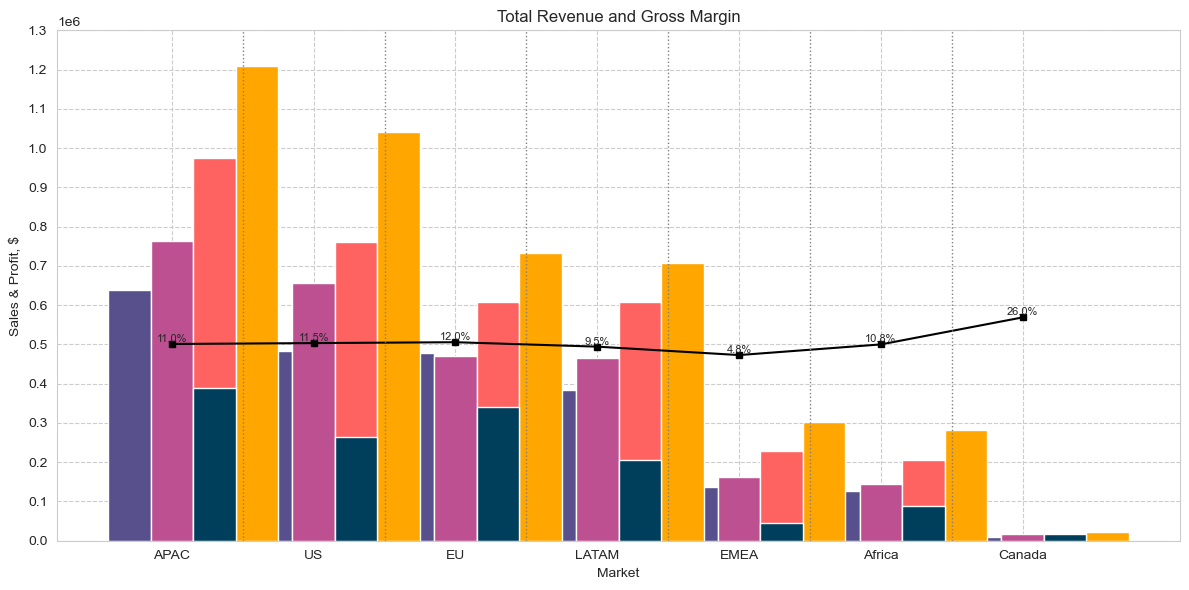

In [30]:
# Visualization of revenue_margin
# Calculate scale and offset for margin line
scale = revenue_margin['sales'].mean()
offset = revenue_margin['sales'].mean()

# Create the plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid", {'grid.linestyle': '--'})

# Get unique markets and their positions for x-axis
markets = revenue_margin['market'].unique()
n_markets = len(markets)
x = np.arange(n_markets)
width = 0.9 / 3  # Adjust width for dodged bars

# Plot sales bars (grouped by year)
years = revenue_margin['order_year'].unique()
for i, year in enumerate(sorted(years)):
    year_data = revenue_margin[revenue_margin['order_year'] == year]
    plt.bar(
        x - width + i * width,
        year_data['sales'],
        width=width,
        label=str(year),
        color={
            2011: "#58508d",
            2012: "#bc5090",
            2013: "#ff6361",
            2014: "#ffa600"
        }[year]
    )

# Plot profit bars
plt.bar(
    x + width,
    revenue_margin.groupby('market')['profit'].sum().reindex(markets),
    width=width,
    label='Profit',
    color="#003f5c"
)

# Plot margin line and points
margin_data = revenue_margin.groupby('market').apply(
    lambda g: offset + g['profit_margin'].mean() * scale
).reindex(markets)

plt.plot(
    x, margin_data,
    color='black',
    marker='s',
    markersize=5,
    label='Gross Margin',
    linestyle='-'
)

# Add margin percentage labels
for i, (market, val) in enumerate(margin_data.items()):
    plt.text(
        i, val,
        f"{revenue_margin[revenue_margin['market'] == market]['profit_margin'].mean():.1%}",
        ha='center', va='bottom', fontsize=8
    )

# Add vertical dotted lines between markets
for i in range(1, n_markets):
    plt.axvline(x=i - 0.5, color='gray', linestyle=':', linewidth=1)

# Configure y-axis
#plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{x/1000:.0f}K"))
plt.ylim(0, 1300000)
plt.yticks(np.arange(0, 1300001, 100000))

# Configure x-axis
plt.xticks(x, markets)

# Add labels and title
plt.title("Total Revenue and Gross Margin")
plt.xlabel("Market")
plt.ylabel("Sales & Profit, $")

plt.tight_layout()
plt.show()



# Configure legend
plt.legend(
    title="Sales",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=5,
    frameon=False,
    handles=[
        lines.Line2D([0], [0], color='black', lw=2, label='Gross Margin'),
        plt.Rectangle((0,0), 1, 1, fc="#003f5c", label='Profit')
    ] + [
        plt.Rectangle((0,0), 1, 1, fc=color, label=str(year))
        for year, color in {
            2011: "#58508d",
            2012: "#bc5090",
            2013: "#ff6361",
            2014: "#ffa600"
        }.items()
    ]
)

# Remove major grid lines
plt.grid(axis='y', which='major', visible=False)

plt.tight_layout()
plt.show()
```

# visualize the result data
from xarray import align


scale = revenue_margin['sales'].mean()
offset = revenue_margin['sales'].mean()

fig, ax = plt.subplots(figsize=(12, 7))

# --- Bar plot for sales by market and year ---
sns.barplot(
    data=revenue_margin,
    x='market', y='sales', hue='order_year',
    dodge=True, ax=ax,edgecolor='white',alpha=0.8,
    palette={2011:'#58508d', 2012:'#bc5090', 2013:'#ff6361', 2014:'#ffa600'}
)
# --- Bar plot for profit ---
sns.barplot(
    data=revenue_margin,
    x='market', y='profit',
    color='#003f5c', dodge=True, ax=ax,alpha=0.6,
    label='Profit'
)


# Add label and title
ax.set_title("Total Revenue and Gross Margin", fontsize=14, fontweight='bold', y=1.10)

# Add legend
ax.legend(loc='upper right', bbox_to_anchor=(0.5, 1.1), ncol=5)
# Add layout
plt.show()

# --- Bar plot for profit ---
sns.barplot(
    data=revenue_margin,
    x='market', y='profit',
    color='#003f5c', dodge=True, ax=ax,
    label='Profit'
)

# --- Line + points for margin ---
for i, row in revenue_margin.iterrows():
    y_val = offset + row['margin'] * scale
    ax.plot(row['market'], y_val, 'o-', color='black')
    ax.text(row['market'], y_val, f"{row['margin']:.0%}",
            ha='center', va='bottom', fontsize=8)

# --- Vertical dotted lines between markets ---
for i in range(1, len(revenue_margin['market'].unique())):
    ax.axvline(i-0.5, linestyle='dotted', color='gray')

# --- Y-axis formatting ---
ax.set_ylim(0, 1300000)
ax.set_yticks(range(0, 1300001, 100000))
ax.set_yticklabels([f"{y//1000}K" for y in range(0, 1300001, 100000)])
ax.set_ylabel("Sales & Profit, $")

# --- Title and labels ---
ax.set_title("Total Revenue and Gross Margin")
ax.set_xlabel("Market")

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Sales", loc="upper center")

sns.despine()
plt.show()

##### **Seasonal Sales Trend**

##### **1. What data do you have?**

To detect seasonality, the dataset should include at least:

- **A date or time column**: This is essential for identifying seasonal patterns. The date column should cover multiple years to capture recurring trends.
- **Inventory related columns**: Columns such as sales, profit, or stock levels are crucial for analyzing seasonal fluctuations in order and return.
- **Possibly Product or category columns**: These can help in understanding if certain products or categories exhibit seasonal trends.


Will analyze daily, weekly, monthly sales trends across years to identify seasonal patterns and peak sales periods. And, visualize which seasonal trend is more clearer and relevant . Total sum or mean of sales seems appropriate for good summary.

order_df.columns

## **Gross & Net Revenue and YoY Profit Growth**

In [31]:
# Compute sales, returned_Sales, profit for each order

order_metrics = (
    order_merged.groupby(['order_id'], as_index=False)
    .agg({
        'order_date': 'first',         # first_value(order date)
        'sales' : 'sum',               # sum(sales) per order
        'profit': 'sum',               # sum(profit) per order
        'returned': 'first'            # first_value(returned)
    })
    .sort_values('order_id')
    .assign(order_year = lambda x: pd.to_datetime(x['order_date']).dt.year)
    .sort_values('order_year')
)
order_metrics.head()
# Compute sales, returned_sales, profit per year
yearly_metrics = (
    order_metrics.groupby(['order_year'], as_index=False)
    .agg(
        sales = ('sales', lambda x: x[~(order_metrics.loc[x.index, 'returned'])].sum()),
        returned_sales = ('sales', lambda x: x[order_metrics.loc[x.index, 'returned']].sum()),
        profit = ('profit', lambda x: x[~(order_metrics.loc[x.index, 'returned'])].sum())
    )
    .round(2)
    .sort_values('order_year')
)
# Compute YoY profit growth
yearly_metrics['yoy_profit_growth'] = (
    yearly_metrics['profit'].pct_change()
    .round(2)
)
display(yearly_metrics.head())

,order_year,sales,returned_sales,profit,yoy_profit_growth
0,2011,2104950.33,154500.57,232259.57,NaN
1,2012,2500155.67,177283.03,278076.87,0.20
2,2013,3216759.73,188986.72,384269.22,0.38
3,2014,4002533.65,297332.22,454789.69,0.18


posx and posy should be finite values
posx and posy should be finite values


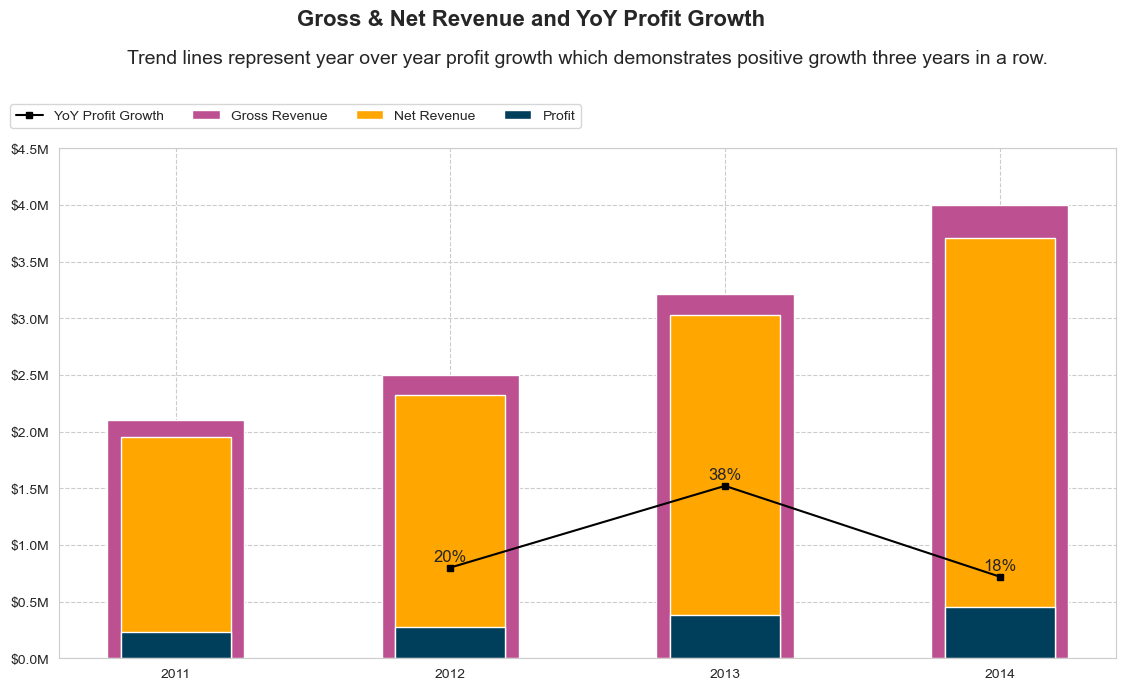

In [32]:
# Creating revenue and YoY profit growth visualization
# Fill NaN with 0 for plotting
#yearly_metrics["yoy_profit_growth"] = yearly_metrics["yoy_profit_growth"].fillna(0)

# Scaling factor for YoY profit growth line
scale = yearly_metrics['sales'].max()
offset = yearly_metrics['sales'].mean()

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Bar plots
ax.bar(yearly_metrics['order_year'], yearly_metrics['sales'], width=0.5, label='Gross Revenue', color='#bc5090')
ax.bar(yearly_metrics['order_year'], yearly_metrics['sales'] - yearly_metrics['returned_sales'],
       width=0.4, label='Net Revenue', color='#ffa600')
ax.bar(yearly_metrics['order_year'], yearly_metrics['profit'], width=0.4, label='Profit', color='#003f5c')

# Line plot for YoY profit growth
ax.plot(yearly_metrics['order_year'], yearly_metrics['yoy_profit_growth'] * scale,
        color='black', marker='s', markersize=4, label='YoY Profit Growth')

# Annotate YoY profit growth percentages
for i, row in yearly_metrics.iterrows():
    y_val = row['yoy_profit_growth'] * scale
    label = f"{row['yoy_profit_growth']*100:.0f}%"
    ax.text(row['order_year'], y_val + 30000, label, ha='center', va='bottom', fontsize=12)

# Y-axis formatting
ax.set_ylim(0, 4500000)
ax.set_yticks(range(0, 4500001, 500000))
ax.set_yticklabels([f"${val/1e6:.1f}M" for val in ax.get_yticks()])

# X-axis formatting
ax.set_xticks([2011, 2012, 2013, 2014])

# Titles and labels
ax.set_title("Trend lines represent year over year profit growth which demonstrates positive growth three years in a row.", fontsize=14, y=1.15)
ax.set_xlabel("")
ax.set_ylabel("")
fig.suptitle("Gross & Net Revenue and YoY Profit Growth", fontsize=16, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor =(0.5, 1.1), ncols=4)

# Save the plot
plt.tight_layout()
plt.show()

## **Quarterly Net Revenue growth**

In [33]:
# -- Trend of quarterly revenue growth

# Aggregate by year and quarter
quarterly = (
    order_merged.groupby(['order_year', 'order_quarter'])
    .agg(
        net_sales = ('sales', lambda x: x[~(order_merged.loc[x.index, 'returned'])].sum()), # exclude returns
        gross_sales = ('sales', 'sum')
    )
).reset_index().sort_values(by=['order_year', 'order_quarter']).round(2)

# Add row number
quarterly['n'] = quarterly.reset_index().index + 1

# Create label column
quarterly['label'] = "Q" + quarterly['order_quarter'].astype(str) + "'" + quarterly['order_year'].astype(str).str[-2:]

# Computer growth rate(quarter-over-quarter growth)
quarterly['growth_rate'] = quarterly['net_sales'].pct_change().round(2)
display(quarterly.head())

,order_year,order_quarter,net_sales,gross_sales,n,label,growth_rate
0,2011,1,319740.40,335780.01,1,Q1'11,NaN
1,2011,2,444865.44,478870.98,2,Q2'11,0.39
2,2011,3,569174.72,613306.37,3,Q3'11,0.28
3,2011,4,771169.76,831493.54,4,Q4'11,0.35
4,2012,1,380496.46,399367.71,5,Q1'12,-0.51


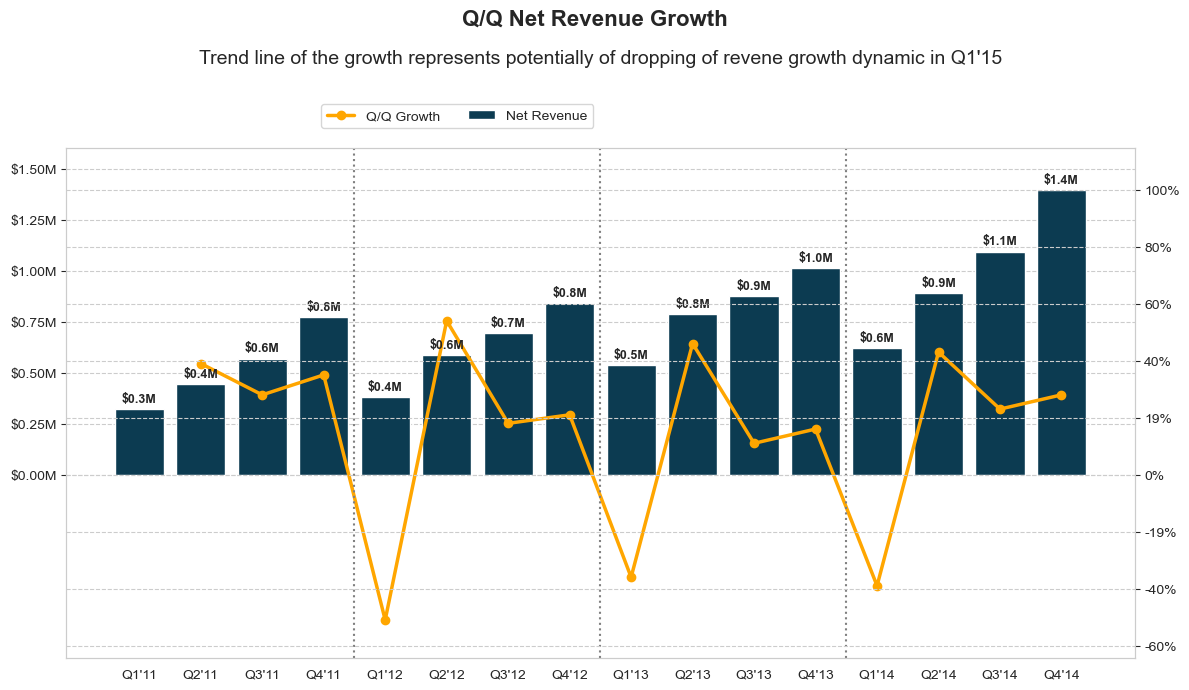

In [34]:
# --- visualization of Quarter Net Revenue Growth
# Reorder labels by 'n'
from matplotlib.ticker import FuncFormatter


quarterly = quarterly.sort_values('n')
scale = quarterly['net_sales'].max()

# Create figure and axis
fig, ax = plt.subplots(figsize=(12,7))

# bar plot for net_sales
sns.barplot(data=quarterly, x='label', y='net_sales', color = '#003f5c', ax=ax, label = 'Net Revenue')
ax.legend()
# Add text labels on bar
for i, v in enumerate(quarterly['net_sales']):
    ax.text(i, v + 20000, f"${v/1e6:.1f}M", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot the line chart for growth
ax.plot(quarterly['label'], quarterly['growth_rate']*scale, color='#ffa600', marker='o', lw = 2.5, label='Q/Q Growth')

# Format the y-axis 
# Set the limits and breaks for the y-axis
ax.set_ylim(-900000, 1600000)
ax.set_yticks(range(0, 1600001, 250000))
ax.set_yticklabels([f"${val/1e6:.2f}M" for val in ax.get_yticks()])

# secondary y-axis for Q/Q growth
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim()[0]/scale, ax.get_ylim()[1]/scale)
ax2.set_yticklabels([f"{int(val*100)}%" for val in ax2.get_yticks()])

# Add Vertical line:
for x in range(4, len(quarterly['label']), 4):
    ax.axvline(x = x - 0.5, ls='dotted', color='gray')

# Add labels and title
fig.suptitle("Q/Q Net Revenue Growth", fontsize=16, fontweight='bold')
ax.set_title("Trend line of the growth represents potentially of dropping of revene growth dynamic in Q1'15", fontsize=14, y=1.15)
ax.set_xlabel("")
ax.set_ylabel("")

# Add legend
ax.legend(loc='upper right', bbox_to_anchor=(0.5, 1.1), ncols=2)
# Add layout
plt.tight_layout()
plt.show()

## **Profit Trends**

In [35]:
# Compute last day of month for each order date
order_merged['last_month_day'] = order_merged['order_date'] + pd.offsets.MonthEnd(0)
# Aggregate profit by 'last_month_day' (excluding returns)
monthly = (
    order_merged[order_merged['returned']==False]
    .groupby(['last_month_day'])
    .agg(
        {'profit': 'sum'}
        )
        ).reset_index().sort_values(by='last_month_day').round(2)

# Compute month-over-month profit growth
monthly['growth_rate'] = monthly['profit'].pct_change().round(2)
monthly['growth_rate'] = monthly['growth_rate'].fillna(0)
display(monthly.head())

,last_month_day,profit,growth_rate
0,2011-01-31,8170.08,0.00
1,2011-02-28,8504.04,0.04
2,2011-03-31,15091.52,0.77
3,2011-04-30,13175.23,-0.13
4,2011-05-31,10862.73,-0.18


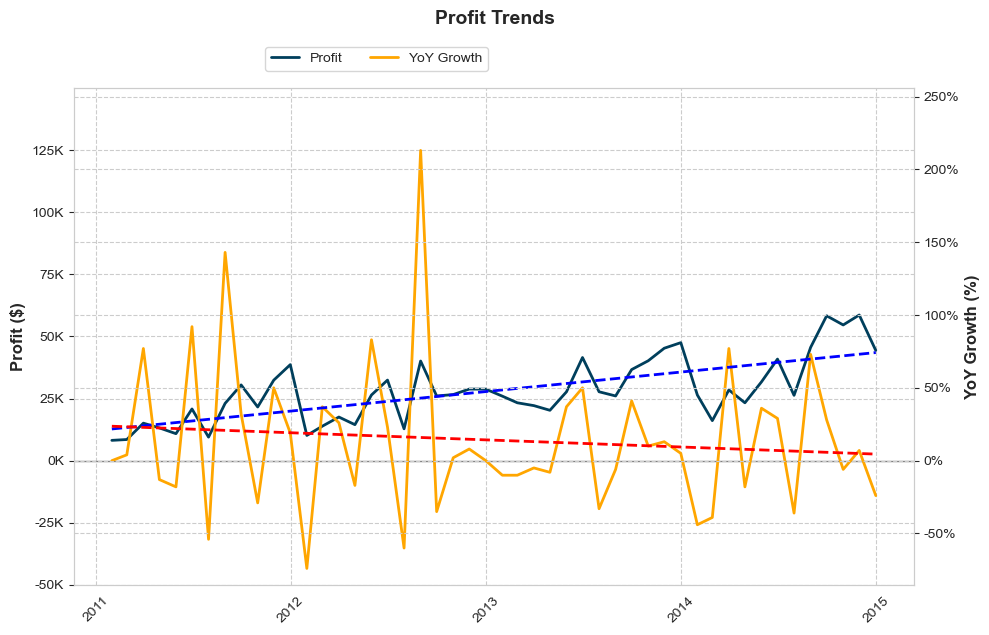

In [36]:
# Visualization of Monthly profit trends
from sklearn.linear_model import LinearRegression
import matplotlib as mpl
# compute scaled variabale
scale = monthly['profit'].max()
monthly = monthly.sort_values(by='last_month_day')

# Add scaled growth column
monthly['growth_scaled'] = monthly['growth_rate'] * scale

# Create plot 
fig, ax1 = plt.subplots(figsize=(10,6))

# Profit line
sns.lineplot(data=monthly, x='last_month_day', y='profit', ax=ax1, color='#003f5c', label='Profit', lw=2)

# Horizontal line at y=0
ax1.axhline(y=0, color='gray', lw=1)

# YoY growth line(scaled)
sns.lineplot(data=monthly, x='last_month_day', y='growth_scaled', ax=ax1, color='#ffa600', label='YoY Growth', lw=2)

# Linear regression for profit
monthly['last_month_day_num'] = (monthly['last_month_day'] - monthly['last_month_day'].min()).dt.days

X = monthly['last_month_day_num'].values.reshape(-1, 1)
y = monthly['profit'].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
ax1.plot(monthly['last_month_day'], y_pred, color='blue', linestyle='--', linewidth=2)


# Linear regression for growth_scaled
y = monthly['growth_scaled'].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
ax1.plot(monthly['last_month_day'], y_pred, color='red', linestyle='--', linewidth=2)

# format x-axis ticks as dates in yearly
ax1.xaxis.set_major_locator(mpl.dates.YearLocator())
ax1.xaxis.set_major_formatter(mpl.dates.DateFormatter('%Y'))
ax1.tick_params(axis='x', rotation=45)

# Primary y-axis formatting
ax1.set_ylim(-50000, 150000)
ax1.set_yticks(np.arange(-50000, 150000, 25000))
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))


# Secondary y-axis for growth
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim()[0]/scale, ax1.get_ylim()[1]/scale)
ax2.set_yticklabels([f"{int(val*100)}%" for val in ax2.get_yticks()])

# Title, labels and leagend
fig.suptitle("Profit Trends", fontsize=14, fontweight='bold', y=1.05)
ax1.set_ylabel("Profit ($)", fontsize=12, fontweight='bold')
ax2.set_ylabel("YoY Growth (%)", fontsize=12, fontweight='bold')
ax1.set_xlabel("")

fig.legend(loc='upper right', bbox_to_anchor=(0.5, 1), ncol=2, bbox_transform=fig.transFigure, frameon=True)
ax1.get_legend().remove()

# Add layouts
plt.tight_layout()
plt.show()

## **Total number of orders and loss orders**

In [37]:
# Aggregate at market-year level (outer query)
# Aggregate at market + year + order_id level
group_df = (
    order_merged.groupby(['market', 'order_year', 'order_id'], as_index=False)
    .agg(
        sales = ('sales', 'sum'),
        profit = ('profit', 'sum')
    )
)

# Aggregate at market + year level
summary_df = (
    group_df.groupby(['market', 'order_year'],as_index=False)
    .agg(
        gross_sales = ('sales', 'sum'),
        total_orders = ('order_id', 'nunique'),
        loss_orders = ('order_id', lambda x: x[group_df['profit'] < 0].nunique())
    )
    .round(2)
)
display(summary_df.head())

,market,order_year,gross_sales,total_orders,loss_orders
0,APAC,2011,639245.26,966,276
1,APAC,2012,762719.33,1182,326
2,APAC,2013,974580.86,1404,404
3,APAC,2014,1209198.69,1885,552
4,Africa,2011,127187.27,382,94


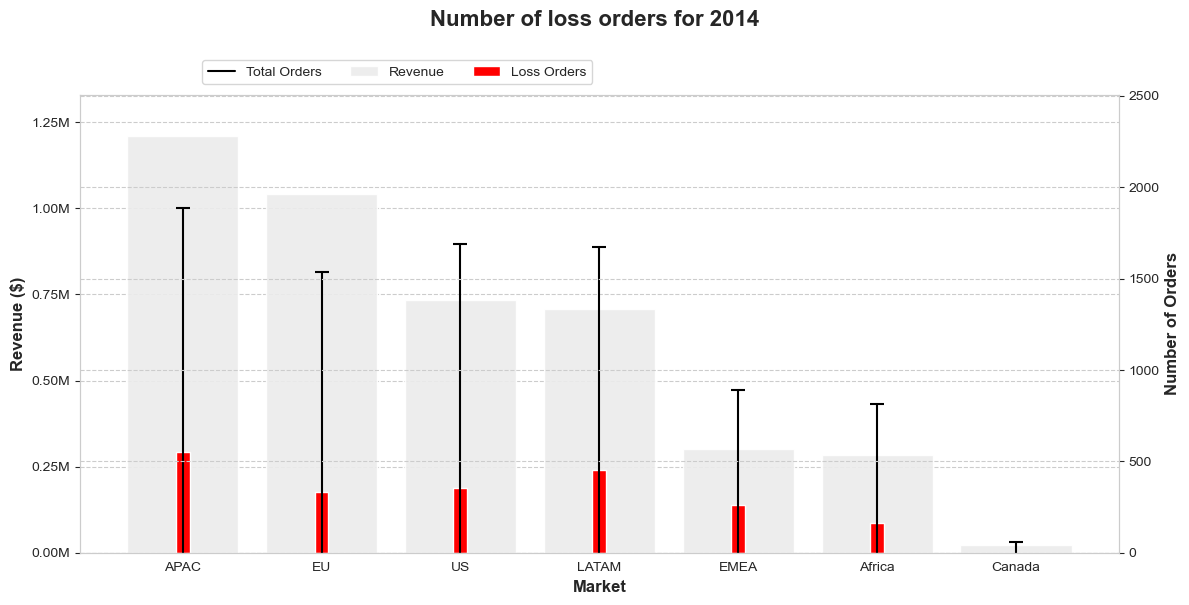

In [38]:
# Visualization of summary_df for year 2014

# Filter for 2014
orders_2014 = summary_df[summary_df['order_year'] == 2014].copy()

# Normalize total_orders and loss_orders to scale with revenue
max_total_orders = orders_2014['total_orders'].max()
orders_2014['total_orders_scaled'] = orders_2014['total_orders'] * 1e6 / max_total_orders
orders_2014['loss_orders_scaled'] = orders_2014['loss_orders'] * 1e6 / max_total_orders

# Sort markets by sales descending
orders_2014 = orders_2014.sort_values('gross_sales', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

# Revenue bars
sns.barplot(
    data=orders_2014,
    x='market', y='gross_sales',
    color='#ececec', alpha=0.9,
    ax=ax, label='Revenue'
    )

# Loss orders bars (thin red overlay)
ax.bar(
    orders_2014['market'],
    orders_2014['loss_orders_scaled'],
    width=0.1, color='red', label='Loss Orders'
)

# Total orders segments and points
for i, row in orders_2014.iterrows():
    ax.plot([row['market'], row['market']], [0, row['total_orders_scaled']], color='black')
    ax.scatter(row['market'], row['total_orders_scaled'], marker='_', s=100, color='black')

# Add one invisible line just for the legend entry
ax.plot([], [], color='black', label='Total Orders')

# Y-axis scaling and Formatting
ai = orders_2014['gross_sales'].max() * 1.1
ax.set_ylim(0, ai)
ax.set_yticks(np.arange(0, ai+1, 250000))
# Format y-axis in millions
ax.set_yticklabels([f"{val/1e6:.2f}M" for val in ax.get_yticks()])

# Add labels and title
ax.set_ylabel('Revenue ($)', fontsize=12, fontweight='bold')
ax.set_xlabel('Market', fontsize=12, fontweight='bold')
fig.suptitle('Number of loss orders for 2014', fontsize=16, fontweight='bold', y=1)

# Secondary axis for number of orders
ax2 = ax.twinx()
ax2.set_ylim((ax.get_ylim()[0]/1e6)* max_total_orders, (ax.get_ylim()[1]/1e6)*max_total_orders)
ax2.set_ylabel('Number of Orders', fontsize=12, fontweight='bold')

# legend
ax.legend(loc='upper right', bbox_to_anchor=(0.5, 1.09), ncols=3)
# Add layout
plt.tight_layout()
plt.show()

## **Customer Lifetime Value (CLV)**

In [39]:
# Aggregate sales by market, segment and year
from typing import final


sales_df = (
    order_merged.groupby(['market', 'segment', 'order_year'], as_index=False)
    .agg(sales = ('sales', 'sum'))
)

# Count the customers by market, segment and year
cust_df = (
    order_merged.groupby(['market', 'segment', 'order_year'], as_index=False)
    .agg(uniq_customers = ('customer_id', 'nunique'))
)

# Merge sales and customers dataframes for customer value
merged_df = (
    sales_df
    .merge(cust_df, on = ['market', 'segment', 'order_year'], how='left')
)
merged_df['customer_value'] = (merged_df['sales'] / merged_df['uniq_customers']).round(2)

# Compute CLV(customer lifetime Value)
# First, get first and last order dates per customer per year
order_merged['first_order'] = order_merged.groupby(['customer_id'], as_index=False)['order_date'].transform('min')
order_merged['last_order'] = order_merged.groupby(['customer_id', 'order_year'],as_index=False)['order_date'].transform('max')

# calculate days between first ans last order
order_merged['days'] = (pd.to_datetime(order_merged['last_order']) - pd.to_datetime(order_merged['first_order'])).dt.days
order_merged.head()

# Aggregate CLV by market, segment and year
cls_agg = (
    order_merged.groupby(['market', 'segment', 'order_year'], as_index=False)
    .agg(
        total_days = ('days', 'sum'),
        unique_customers = ('customer_id', 'nunique')
    )
)
cls_agg['cls'] = ((cls_agg['total_days'] / 365) / (cls_agg['unique_customers'])).round(2)

# merge CLV with customer_value
final_df = pd.merge(merged_df, cls_agg, on = ['market', 'segment', 'order_year'])
final_df['clv'] = (final_df['customer_value'] * final_df['cls']).round(2)

# Compute growth using lag
final_df.sort_values(by = ['market', 'segment', 'order_year'], inplace=True)
final_df['growth_yoy'] = final_df.groupby(['market', 'segment'])['clv'].pct_change()

# Final result
result = final_df[["market", "segment", "order_year", "clv", "growth_yoy"]]
display(result.head().round(2))

,market,segment,order_year,clv,growth_yoy
0,APAC,Consumer,2011,2262.69,NaN
1,APAC,Consumer,2012,7518.36,2.32
2,APAC,Consumer,2013,16858.67,1.24
3,APAC,Consumer,2014,29676.61,0.76
4,APAC,Corporate,2011,2742.68,NaN


<Figure size 1400x800 with 0 Axes>

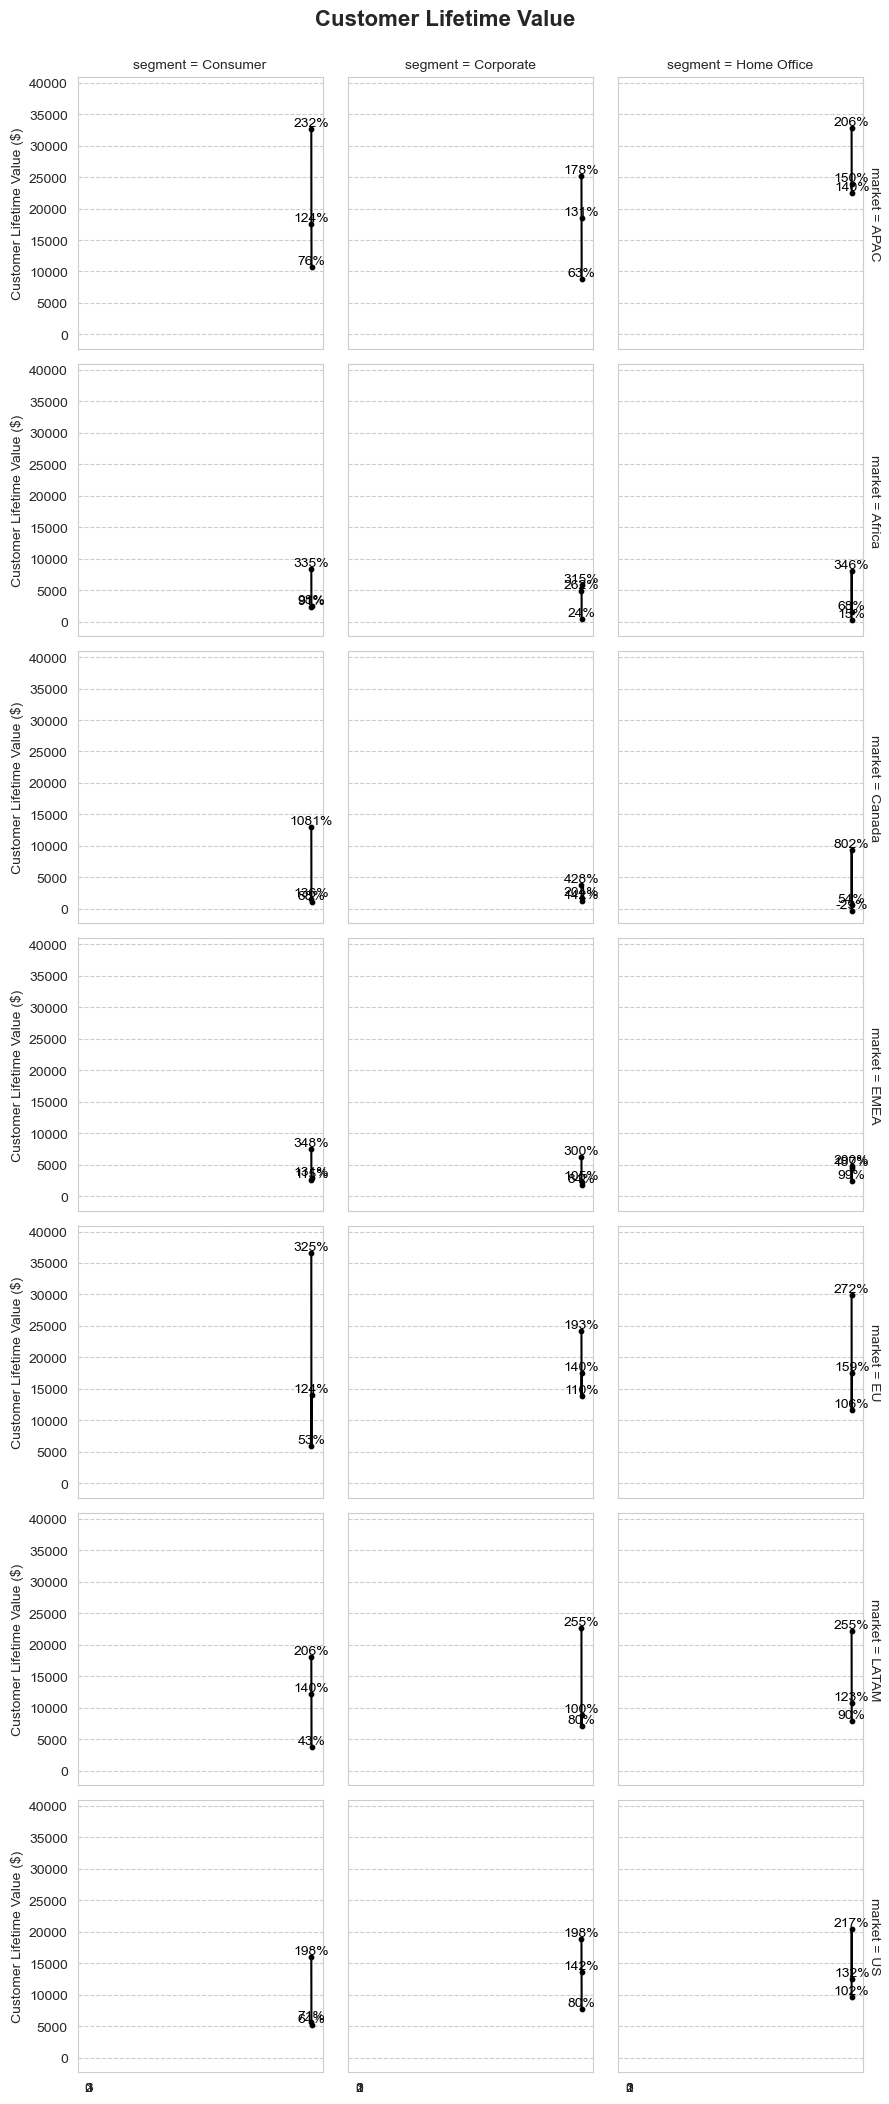

In [40]:
clv_df = result.copy()
#clv_df['growth_yoy'] = clv_df['growth_yoy'].fillna(0)
# Visualization of clv_df
# Define custome colors for segment
segment_colors = {
    'Consumer': "#ff6461",
    'Corporate': '#bc5090',
    'Home Office': '#ffa600'
}
plt.figure(figsize=(14, 8))
# Facetgrid: market ~ segment
g = sns.FacetGrid(clv_df, row='market', col='segment',
                  margin_titles=True, despine=False, sharex=True, sharey=True)
# Map bar plot of clv by year with segment
g.map_dataframe(
    sns.barplot,
    x='order_year', y='clv', hue='segment',
    palette = segment_colors, dodge=True
)
# Overlay YoY growth line + point and text
for ax, ((market, seg), sub_df) in zip(g.axes.flat, clv_df.groupby(["market","segment"])):
    # compute mean CLV for this facet
    scale = sub_df['clv'].mean()
    # growth line values
    y_growth = sub_df['growth_yoy'] * scale
    # Ensure year is numeric for proper line plotting
    sub_df['years'] = sub_df["order_year"].astype(int)
    # YoY growth line + point
    ax.plot(sub_df['years'], y_growth, color='black', label='YoY Growth')  # skip NaN automatically
    # Points (only finite values)
    #valid_mask = pd.notna(y_growth) & np.isfinite(y_growth)
    ax.scatter(sub_df["years"],y_growth,color="black", s=10)
    # Add growth labels
    for x, y, growth in zip(sub_df['years'], y_growth, sub_df['growth_yoy']):
        if pd.notna(y) and np.isfinite(y):
            ax.text(x, y, f"{growth:.0%}",
                    ha='center', va='bottom', color='k')
    
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
    ax.set_ylabel("Customer Retention Rate ($)")
# Add title and labels
g.set_axis_labels("", "Customer Lifetime Value ($)")
g.fig.suptitle(f"Customer Lifetime Value", fontsize=16, fontweight='bold', y=1)



# Add layout
plt.tight_layout()
plt.show()

In [41]:

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Assuming CLV is a pandas DataFrame with columns: year, clv, segment, market, growth
# Example data structure:
CLV = pd.DataFrame({
    'year': [2020, 2021, 2022, 2020, 2021, 2022],
     'clv': [100, 120, 150, 80, 90, 110],
     'segment': ['Consumer', 'Consumer', 'Consumer', 'Corporate', 'Corporate', 'Corporate'],
     'market': ['Market1', 'Market1', 'Market1', 'Market2', 'Market2', 'Market2'],
     'growth': [np.nan, 0.25, 0.3, 0.15, 0.18, 0.2]
 })

# Calculate mean CLV for each market and segment combination
mean_clv = CLV.groupby(['market', 'segment'])['clv'].mean().reset_index()

# Merge mean CLV back to the original DataFrame
CLV = pd.merge(CLV, mean_clv, on=['market', 'segment'], suffixes=('', '_mean'))

# Create a color mapping for segments
segment_colors = {
    'Consumer': '#ff6361',
    'Corporate': '#bc5090',
    'Home Office': '#ffa600'
}

# Create subplots for each market-segment combination
unique_markets = CLV['market'].unique()
unique_segments = CLV['segment'].unique()

fig = make_subplots(
    rows=len(unique_markets),
    cols=len(unique_segments),
    subplot_titles=[f"{market} - {segment}" for market in unique_markets for segment in unique_segments],
    vertical_spacing=0.1,
    horizontal_spacing=0.05
)

# Add bar traces for each market-segment combination
for i, market in enumerate(unique_markets, start=1):
    for j, segment in enumerate(unique_segments, start=1):
        df_segment = CLV[(CLV['market'] == market) & (CLV['segment'] == segment)]

        # Bar trace
        fig.add_trace(
            go.Bar(
                x=df_segment['year'],
                y=df_segment['clv'],
                name=segment,
                marker_color=segment_colors[segment],
                showlegend=(i == 1 and j == 1)  # Only show legend for first subplot
            ),
            row=i, col=j
        )

        # Line and point traces for growth
        fig.add_trace(
            go.Scatter(
                x=df_segment['year'],
                y=df_segment['growth'] * df_segment['clv_mean'],
                mode='lines+markers+text',
                name='YoY Growth',
                line=dict(color='black'),
                marker=dict(size=5),
                text=[f"{growth*100:.1f}%" for growth in df_segment['growth']],
                textposition='top center',
                showlegend=(i == 1 and j == 1)  # Only show legend for first subplot
            ),
            row=i, col=j
        )

# Update layout
fig.update_layout(
    title_text="Customer Lifetime Value",
    height=600 * len(unique_markets),
    width=800 * len(unique_segments),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    yaxis_title="Customer Lifetime Value, $"
)

# Update axes for each subplot
for i in range(1, len(unique_markets) + 1):
    for j in range(1, len(unique_segments) + 1):
        fig.update_yaxes(title_text="", row=i, col=j)

# Show the figure
fig.show()

## **Quarterly Customer Retention Rate**

In [42]:
# commpute first_date per customer + market
order_merged['first_date'] = order_merged.groupby(['customer_id','market'])['order_date'].transform(min)
# Extract year/quarter for first_date
order_merged['first_year'] = order_merged['first_date'].dt.year
order_merged['first_quarter'] = order_merged['first_date'].dt.quarter

# Aggregate by year, quarter, market, segment
grouped = (
    order_merged.groupby(['order_year', 'order_quarter', 'market', 'segment'],as_index=False)
    .agg(
        uniq_customer = ('customer_id', 'nunique'),
        new_customer = ('customer_id',
                        lambda x: x[
                            (order_merged.loc[x.index, 'order_year'] == order_merged.loc[x.index, 'first_year']) &
                            (order_merged.loc[x.index, 'order_quarter'] == order_merged.loc[x.index, 'first_quarter'])
                        ].nunique()
                        )
    )
)

# Add sequential row number per market + segment ordered by year and quarter
grouped['n'] = (
    grouped.sort_values(by=['order_year', 'order_quarter'])
    .groupby(['market', 'segment'])
    .cumcount()+1
)

# Quarter label
grouped['qy'] = grouped.apply(
    lambda row : f"Q{int(row['order_quarter'])}'{str(row['order_year'])[-2:]}",
    axis='columns'
)
# Retention rate
grouped["ret_rate"] = (
    (grouped["uniq_customer"] - grouped["new_customer"].fillna(0))
    / grouped.groupby(["market","segment"])["uniq_customer"].shift(1)
).round(2)

display(grouped.head())

,order_year,order_quarter,market,segment,uniq_customer,new_customer,n,qy,ret_rate
0,2011,1,APAC,Consumer,80,80,1,Q1'11,NaN
1,2011,1,APAC,Corporate,40,40,1,Q1'11,NaN
2,2011,1,APAC,Home Office,24,24,1,Q1'11,NaN
3,2011,1,Africa,Consumer,40,40,1,Q1'11,NaN
4,2011,1,Africa,Corporate,22,22,1,Q1'11,NaN


<Figure size 1400x800 with 0 Axes>

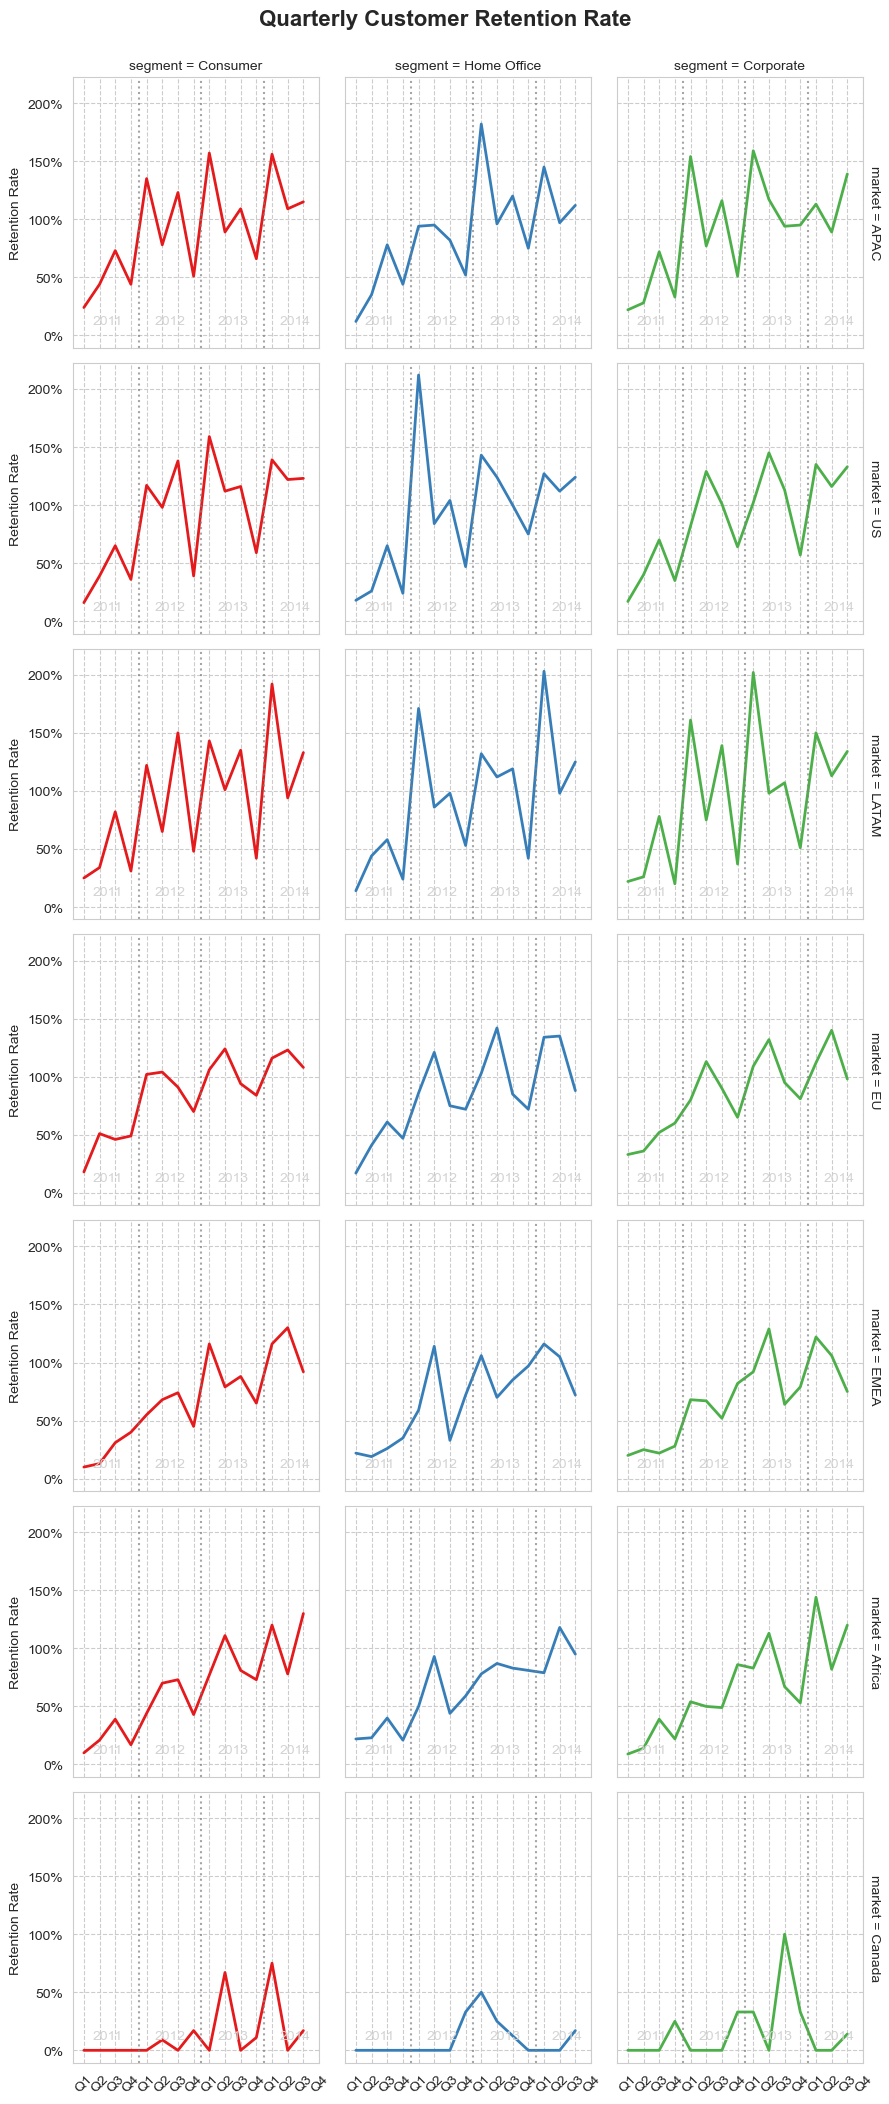

In [43]:
# Visualiztion of grouped dataframe
# Reorder qy by n
from cProfile import label
from matplotlib import legend


customer_retention = grouped.sort_values('n').reset_index(drop=True)

plt.figure(figsize=(14,8))
# Facetgrid : market ~ segment
g = sns.FacetGrid(customer_retention, row='market', col='segment',hue='segment',palette='Set1',
                  margin_titles=True, despine=False, sharex= True, sharey=True)
# map line plots with segment
g.map_dataframe(
    sns.lineplot,
    x='qy', y='ret_rate',
    linestyle='-', linewidth=2, legend=True
)

# Add vertical lines + annotations
for ax in g.axes.flat:
    # vertical dotted lines at 4.5, 8.5, 12.5
    for xpos in [4.5, 8.5, 12.5]:
        ax.axvline(xpos, linestyle='dotted', color='gray', alpha=0.7)
    # Year annotaion
    year_labels = [
        (2.5, 2011),
        (6.5, 2012),
        (10.5, 2013),
        (14.5, 2014)
    ]
    for x, label in year_labels:
        ax.text(x, 0.1, label, color='lightgray', ha='center')

    # Format y-axis as percentage
    ax.set_yticklabels([f"{val:.0%}" for val in ax.get_yticks()])
    # customize x-axis
    ax.set_xticks(range(1, 17))
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4']*4, rotation=45)

    # Title and labels
    g.set_axis_labels("", 'Retention Rate')
    g.fig.suptitle("Quarterly Customer Retention Rate", fontsize=16, fontweight='bold',y=1)
    plt.subplots_adjust(top=0.9)

plt.tight_layout()
plt.show()

## **ARPPU and Average check value**

In [44]:
# Group by last day of month
monthly_df = (
    order_merged.groupby("last_month_day")
      .agg(
          uniq_customers=("customer_id", "nunique"),
          count_orders=("order_id", "nunique"),
          total_sales=("sales", "sum")
      )
      .reset_index()
      .sort_values("last_month_day")
)

# Step 4: Compute ARPPU and Avg Check
monthly_df["arppu"] = (monthly_df["total_sales"] / monthly_df["uniq_customers"]).round(2)
monthly_df["avg_check"] = (monthly_df["total_sales"] / monthly_df["count_orders"]).round(2)

# drop sales
monthly_df.drop(columns=['total_sales'], inplace=True)
display(monthly_df.head())

,last_month_day,uniq_customers,count_orders,arppu,avg_check
0,2011-01-31,199,216,496.98,457.86
1,2011-02-28,168,183,542.57,498.10
2,2011-03-31,242,277,602.19,526.10
3,2011-04-30,241,267,485.13,437.89
4,2011-05-31,255,295,575.48,497.45


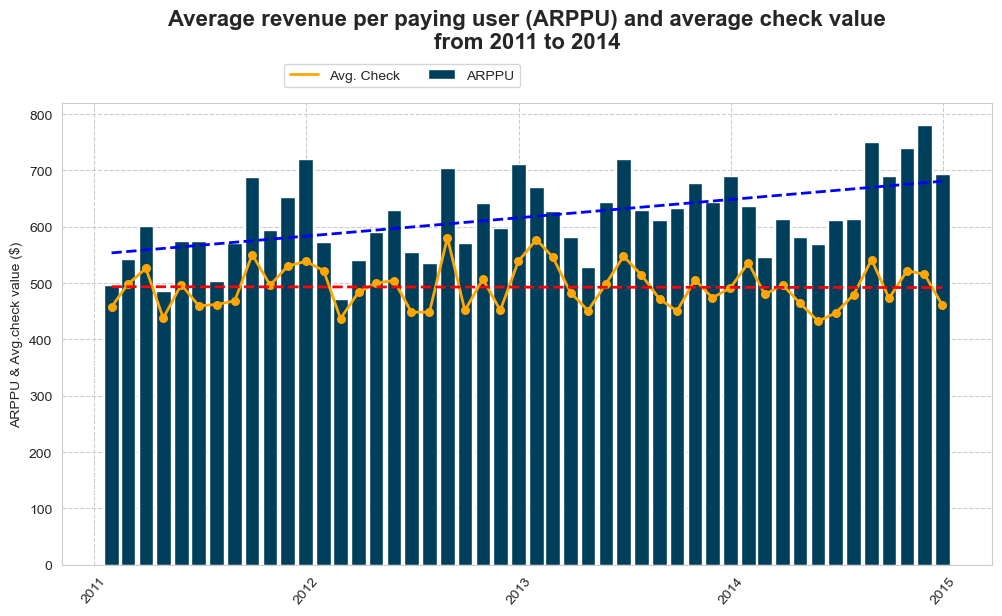

In [45]:
# Visualization of ARPPU and Average check
import matplotlib as mpl
from sklearn.linear_model import LinearRegression

arppu_check = monthly_df.sort_values('last_month_day')

fig, ax1 = plt.subplots(figsize=(12,6))

# plot the number of sales as a series of vertical bars
ax1.bar(arppu_check['last_month_day'], arppu_check['arppu'], width=25, color='#003f5c', label='ARPPU')

# plot line + scatter for avg_check
sns.lineplot(data=arppu_check, x='last_month_day', y='avg_check',ax=ax1, color='#ffa600', linewidth=2, label='Avg. Check')
ax1.scatter(arppu_check['last_month_day'], arppu_check['avg_check'], color='#ffa600', marker='o',s=30, label=None)

# Linear regression for Avg. check
arppu_check['last_month_day_num'] = (arppu_check['last_month_day'] - arppu_check['last_month_day'].min()).dt.days

X = arppu_check['last_month_day_num'].values.reshape(-1, 1)
y = arppu_check['avg_check'].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
ax1.plot(arppu_check['last_month_day'], y_pred, color='red', linestyle='--', linewidth=2)

# Linear regression for ARPPU
y = arppu_check['arppu'].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
ax1.plot(arppu_check['last_month_day'], y_pred, color='blue', linestyle='--', linewidth=2)


# format the x-axis ticks as dates in yearly 
# the format is datetime64[ns]
ax1.xaxis.set_major_locator(mpl.dates.YearLocator())  # Year
ax1.xaxis.set_major_formatter(mpl.dates.DateFormatter('%Y'))
# rotate the x-axis tick labels for readability
ax1.tick_params(axis='x', rotation=50)

# Labels and title
ax1.set_title("Average revenue per paying user (ARPPU) and average check value\nfrom 2011 to 2014", fontsize=16, fontweight='bold', y=1.10)
ax1.set_ylabel("ARPPU & Avg.check value ($)")
ax1.set_xlabel("")

# Legend at top
ax1.legend(loc="upper right", bbox_to_anchor=(0.5, 1.1), ncol=2)


plt.show()



## **Average Basket Value and size**

In [46]:
# -- average basket value and size
# create order_cost
order_cost = (
    order_merged.groupby(['market', 'last_month_day', 'segment', 'order_id'], as_index=False)
    .agg({
        'sales': lambda x: round(x.sum(),2),
        'quantity': lambda x: round(x.sum(), 2)
    })
    .sort_values(by=['last_month_day', 'market', 'segment', 'order_id'])
)
order_cost.head()

# Aggregate to get basket value and basket size
avg_basket = (
    order_cost.groupby(['market', 'last_month_day'], as_index=False)
    .agg({
        'sales' : lambda x: round(x.mean(), 2),
        'quantity' : lambda x: round(x.mean(), 0)
    })
    .rename(columns = {'sales': 'basket_value', 'quantity': 'basket_size'})
)

# compute scale = min(basket_value)/max(basket_size) per market
min_basket_value = avg_basket.groupby(['market'])['basket_value'].transform('min')
max_basket_size = avg_basket.groupby(['market'])['basket_size'].transform('max')

avg_basket['scale'] = (min_basket_value / max_basket_size).round(2)
avg_basket['basket_size'] = avg_basket['basket_size'].astype('int')
display(avg_basket.head())

,market,last_month_day,basket_value,basket_size,scale
0,APAC,2011-01-31,443.45,6,41.36
1,APAC,2011-02-28,724.26,7,41.36
2,APAC,2011-03-31,541.96,7,41.36
3,APAC,2011-04-30,685.57,9,41.36
4,APAC,2011-05-31,682.61,7,41.36


<Figure size 1000x600 with 0 Axes>

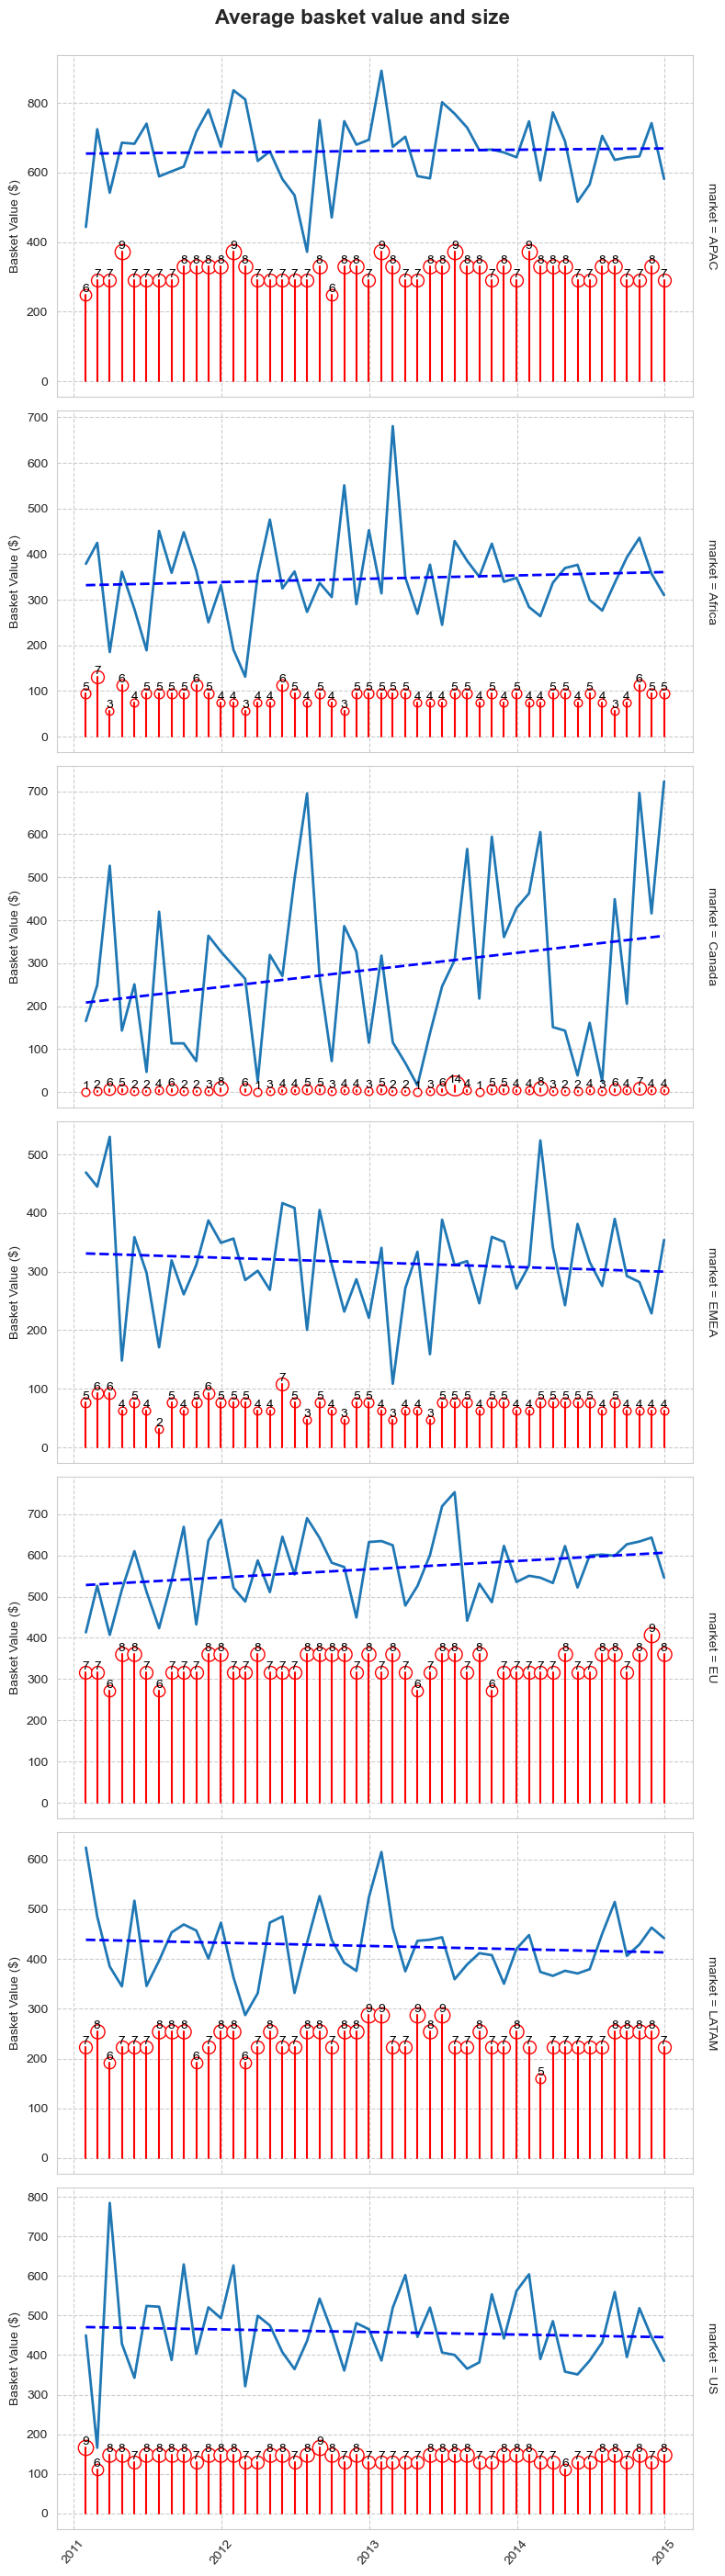

In [47]:
# Visualization of avg_basket
plt.figure(figsize=(10, 6))
# Facetgrid: market
g = sns.FacetGrid(avg_basket, row='market', palette='Set1', margin_titles=True, despine=False, sharey=False, height=4, aspect=2)
# map line plot of basket_value over time
g.map_dataframe(
    sns.lineplot,
    x='last_month_day', y='basket_value',
    linewidth=2
)
# Add segment, point and text labels
# Add vertical lines (segment) from y=0 to y= basket_size * scale
for ax, (market, data) in zip(g.axes.flat, avg_basket.groupby(['market'])):
    for _, row in data.iterrows():
        ax.plot([row['last_month_day'], row['last_month_day']],
                [0, row['basket_size'] * row['scale']], color='red')
        # Add points at the top of vertical line
        size = 2 if row['basket_size'] <= 3 else row['basket_size'] - 2
        ax.scatter(row['last_month_day'], row['basket_size'] * row['scale'],
                   s = size*20, facecolors='white', edgecolors='red')
        # Add text labels for basket_size
        ax.text(row['last_month_day'], row['basket_size'] * row['scale'],
                row['basket_size'], color='k', ha='center', va='bottom')
    # Add regression line between basket_value and time
    data['last_month_day_numeric'] = (data['last_month_day'] - data['last_month_day'].min()).dt.days
    X = data['last_month_day_numeric'].values.reshape(-1, 1)
    y = data['basket_value'].values
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    ax.plot(data['last_month_day'], y_pred, color='blue', linestyle='--', linewidth=2)

    # format x-axis ticks as dates in yearly
    ax.xaxis.set_major_locator(mpl.dates.YearLocator()) # Year
    ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%Y'))
    # rotate the x-axis labels for readability
    ax.tick_params(axis='x', rotation =50)

# Formatting
g.set_axis_labels("", "Basket Value ($)")
g.fig.suptitle("Average basket value and size", fontsize=16, fontweight='bold',y=1)

# Add layout
plt.tight_layout()
#plt.subplots_adjust(top=0.9)
plt.show()

## **Return Rate**

In [48]:
# Group by year and compute aggregate
result = (
    order_merged.groupby(['order_year'], as_index=False)
    .agg(
        total_sales = ('sales', lambda x: round(x.sum(), 2)),
        returned_sales = ('sales', lambda x: round(x[order_merged.loc[x.index, 'returned']].sum(), 2)),
        total_orders = ('order_id', lambda x: x.nunique()),
        returned_orders = ('order_id', lambda x: x[order_merged['returned']==True].nunique()) 
    )
    .sort_values(by='order_year')
)

# compute return_rate
result['return_rate'] = (result['returned_orders'] / result['total_orders']).round(3)
display(result)

,order_year,total_sales,returned_sales,total_orders,returned_orders,return_rate
0,2011,2259450.90,154500.57,4440,209,0.047
1,2012,2677438.69,177283.03,5343,258,0.048
2,2013,3405746.45,188986.72,6721,317,0.047
3,2014,4299865.87,297273.82,8531,388,0.045


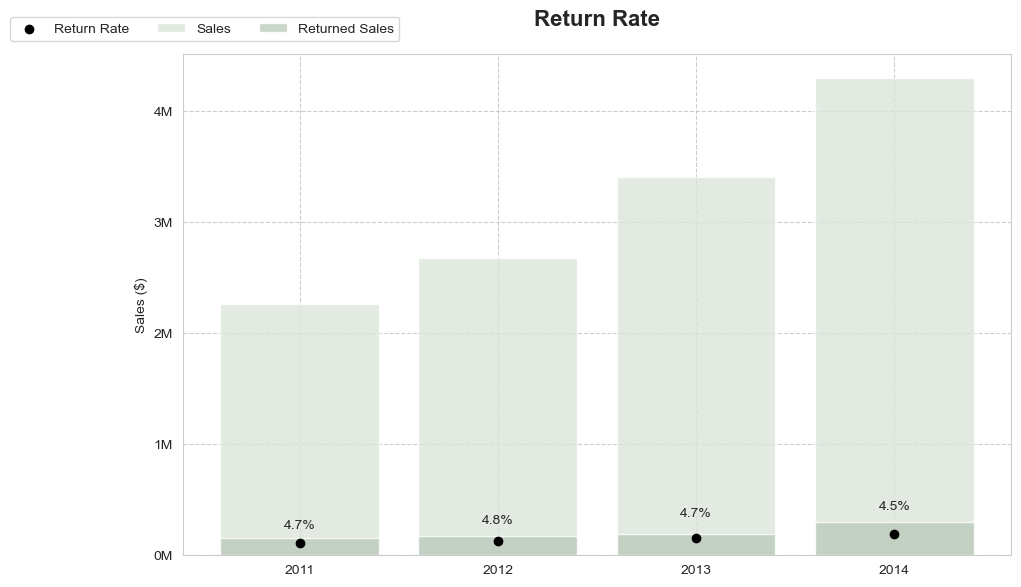

In [49]:
# visulaize result dataframe for return_rate
fig, ax = plt.subplots(figsize=(10,6))
# bar plot for total_sales
ax.bar(result['order_year'], result['total_sales'],color="#dbe5da", label="Sales", alpha=0.8)
# bar plot for total_sales
ax.bar(result['order_year'], result['returned_sales'],color="#bbcbbc", label="Returned Sales", alpha=0.8)
# line plot for return_rate
result['scale'] = result['return_rate'] * result['total_sales']
ax.scatter(result['order_year'], result['scale'], color='black', label='Return Rate')

# Add labels for return rate
for i, rate in enumerate(result['return_rate']):
    year = result['order_year'].iloc[i]
    value = rate * result['total_sales'].iloc[i]
    ax.text(year, value * 2,
    f"{rate:.1%}", ha='center', va='bottom')#, fontsize=8, fontweight='bold')

# Add title, label and legend
ax.set_title("Return Rate", fontsize=16, fontweight='bold', y=1.04)
ax.set_xlabel("")
ax.set_xticks([2011, 2012, 2013, 2014]) # Explicitly set xticks
ax.set_ylabel("Sales ($)")
# format y-axis in millions
ax.set_yticklabels([f"{val/1e6:.0f}M" for val in ax.get_yticks()])
ax.legend(loc='upper right', bbox_to_anchor=(0.38, 0.97), bbox_transform=fig.transFigure, ncols=3)
plt.tight_layout()
plt.show()

## **What most significant sub-categories?**

In [50]:
# Aggregate by year, sub-category, segment
cys_sales = (
    order_merged.groupby(['order_year', 'sub-category', 'segment'], as_index=False)
    .agg(
        sales = ('sales', 'sum'),
        profit = ('profit', 'sum')
    )
)

# compute total_sales per (year, segment)
cys_sales['total_sales'] = cys_sales.groupby(['order_year', 'segment'])['sales'].transform('sum').round(2)

# sort by year, segment and sales descending
cys_sales = cys_sales.sort_values(by = ['order_year', 'segment', 'sales'], ascending=[True, True, False])

# Compute cumulative percentage of sales within each (year, segment)
#cys_sales['sales_ratio'] = cys_sales['sales'] / cys_sales['total_sales']
#cys_sales['new_pct'] = cys_sales.groupby(['order_year', 'segment'])['sales_ratio'].cumsum().round(2). these 2 lines will give same 'cum_percent'
cys_sales['cum_percent'] = (
    cys_sales.groupby(['order_year', 'segment'])['sales']
    .cumsum() / cys_sales['total_sales']
    
).round(2)

# will analyze only sales columns for per year + segment + sub-category	
cys_sales = cys_sales[['order_year', 'sub-category', 'segment', 'sales', 'total_sales', 'cum_percent']].round(2).reset_index(drop=True)
display(cys_sales.head())

,order_year,sub-category,segment,sales,total_sales,cum_percent
0,2011,Phones,Consumer,186824.69,1173671.28,0.16
1,2011,Chairs,Consumer,150154.41,1173671.28,0.29
2,2011,Bookcases,Consumer,132231.69,1173671.28,0.40
3,2011,Storage,Consumer,112624.13,1173671.28,0.50
4,2011,Copiers,Consumer,112032.82,1173671.28,0.59


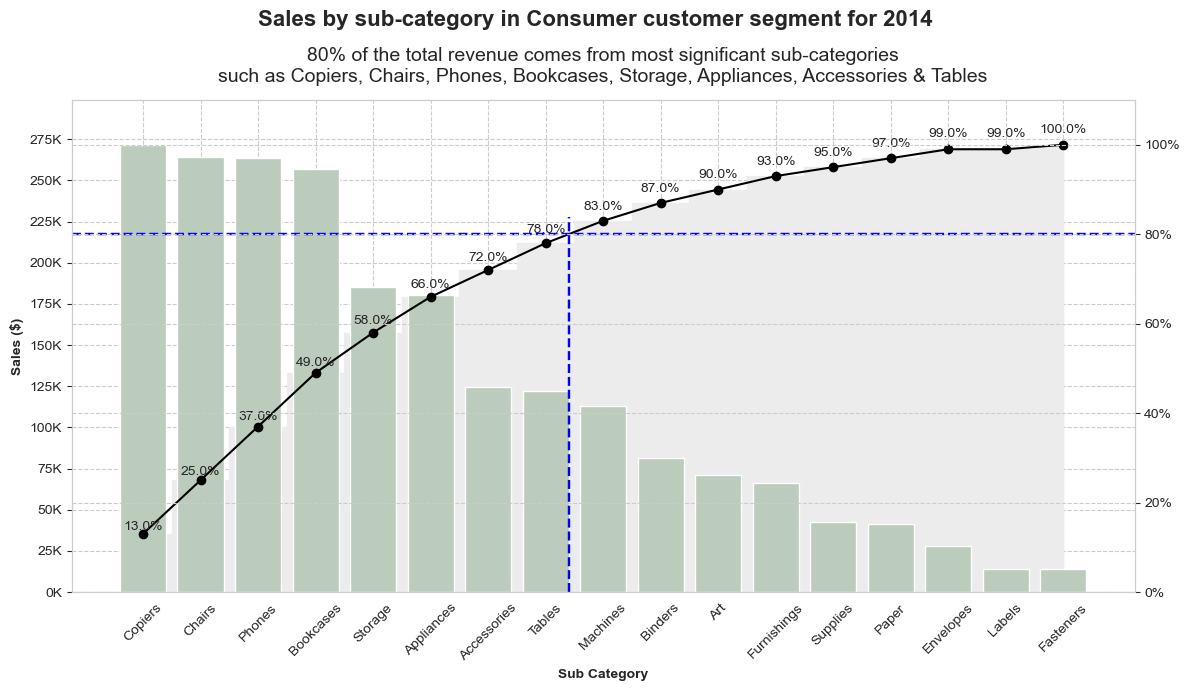

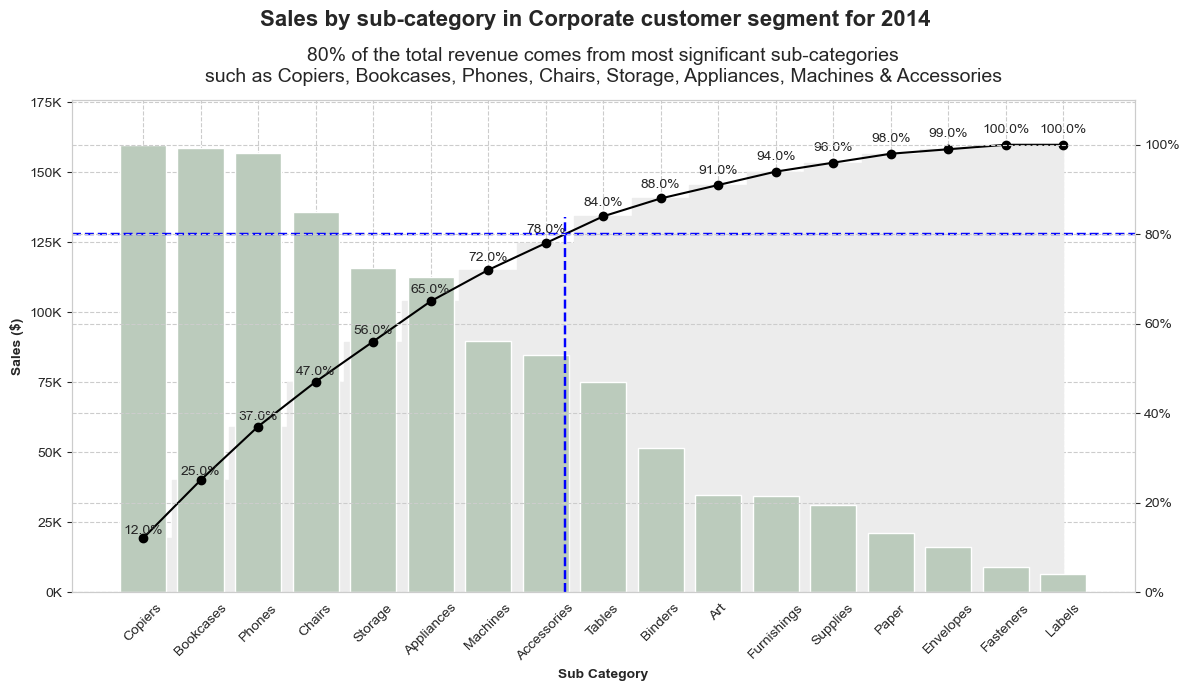

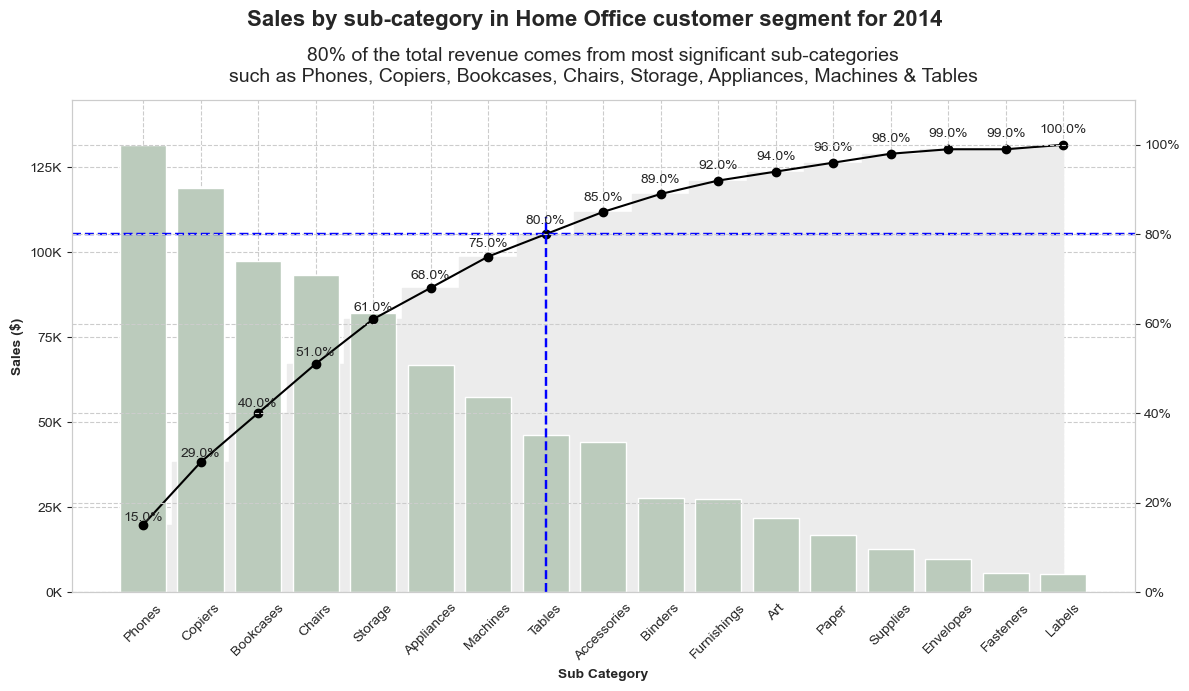

In [51]:
# Visualization of cys_sales
# Filter cys_sales data for segment and year

from numpy import interp

for i, seg in enumerate(cys_sales['segment'].unique()):
    seg_df = cys_sales[(cys_sales['order_year']==2014) & 
                       (cys_sales['segment']==seg)].copy()
    # Sort sales by sub-category
    seg_df = seg_df.sort_values(['sales'], ascending=False)

    scale = seg_df['sales'].max()

    # Approximate x_intercept: find where cum_percent*scale crosses 0.8*scale(seg_df['cum_percent] * 0.8 >= 0.8 * scale)
    scale = seg_df['sales'].max()
    target = 0.8 * scale

    x_vals = np.arange(len(seg_df))  # positions of sub_categories
    y_vals = seg_df['cum_percent'] * scale
    # Interpolate to find x where y crosses target
    x_intercept = interp(target, y_vals, x_vals)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12,7))

    # Area plot for cum_percent * scale
    ax.fill_between(seg_df['sub-category'], seg_df['cum_percent'] * scale, color='#ececec', step='mid')

    # bar plot for sales
    ax.bar(seg_df['sub-category'], seg_df['sales'], color='#bbcbbc')

    # line + point plot for cum_percent * scale
    ax.plot(seg_df['sub-category'], seg_df['cum_percent'] * scale, color='k')
    ax.scatter(seg_df['sub-category'], seg_df['cum_percent'] * scale, color='k')

    # Text labels for cum_percent
    for i, row in seg_df.iterrows():
        ax.text(row['sub-category'], row['cum_percent'] * scale * 1.02,
                f"{row['cum_percent']:.1%}", ha='center', va='bottom', fontsize=10)
    

    # Horizontal line at 80% of scale
    ax.axhline(0.8 * scale, linestyle='--', linewidth=1.75, color='blue')

    # Vertical line at x_intercept
    ax.axvline(x_intercept, linestyle='--', linewidth=1.75, color='blue', ymin=0, ymax=(0.8 * scale)/ax.get_ylim()[1])

    # Formatting axis and labeling as well
    ax.set_ylim(0, scale * 1.1)
    ax.set_yticks(np.arange(0, scale * 1.1 +1, 25000))
    ax.set_yticklabels([f"{val/1000:.0f}K" for val in ax.get_yticks()])
    ax.set_ylabel("Sales ($)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Sub Category", fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

    # Secondary y-axis for percent
    ax2 = ax.twinx()
    ax2.set_ylim((ax.get_ylim()[0]/scale), (ax.get_ylim()[1]/scale))
    ax2.set_yticklabels([f"{int(val*100)}%" for val in ax2.get_yticks()])

    # Add sub-tiles and title
    # Select sub-categories until cumulative crosses 80% of scale
    top_subcats = seg_df.loc[seg_df['cum_percent'] * scale <= 0.8 * scale, 'sub-category']

    # Format subtitle text
    if len(top_subcats) > 1:
        subtitle_text = ", ".join(top_subcats[:-1]) + " & " + top_subcats.iloc[-1]
    else:
        subtitle_text = top_subcats.iloc[0]
    ax.set_title(f"80% of the total revenue comes from most significant sub-categories\nsuch as {subtitle_text}",fontsize=14, y=1.02)
    fig.suptitle(f"Sales by sub-category in {seg} customer segment for 2014", fontsize=16, fontweight='bold')


    # Add layout
    plt.tight_layout()
    plt.show()

## **Map**

In [52]:
# Group by market, region, country and sales sum
map_df = (
    order_merged.groupby(['market', 'region', 'country'],as_index=False)
    .agg(sales = ('sales', 'sum'))
    .round(2)
    .sort_values(by = ['market', 'region', 'country'])
) 
display(map_df.head())

,market,region,country,sales
0,APAC,Central Asia,Afghanistan,21673.32
1,APAC,Central Asia,Bangladesh,78256.47
2,APAC,Central Asia,India,589650.10
3,APAC,Central Asia,Nepal,3522.24
4,APAC,Central Asia,Pakistan,58872.61


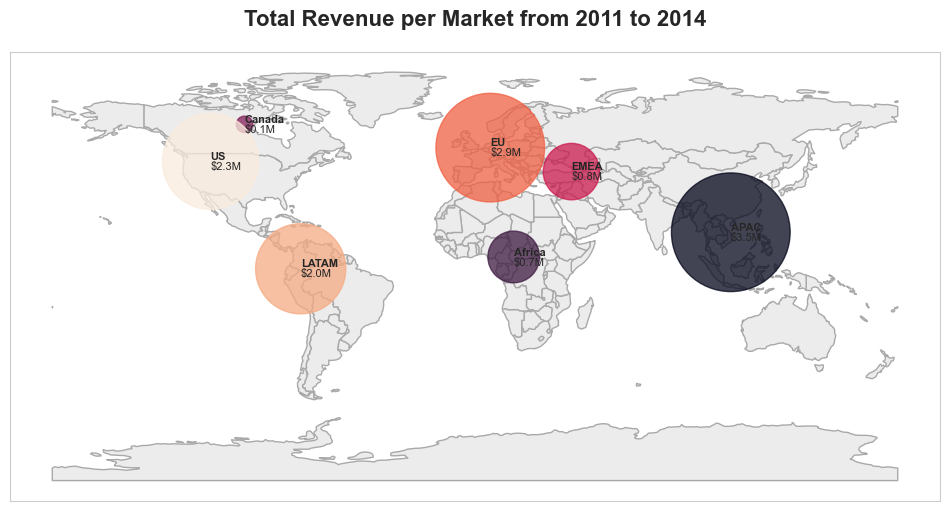

In [53]:
import cartopy.io.shapereader as shpreader
import os
import geopandas as gpd
# Get Natural Earth shapefile path using Cartopy's shpreader
shapefile_path = shpreader.natural_earth(
    resolution='110m',  # Options: '110m', '50m', '10m'
    category='cultural',
    name='admin_0_countries'  # World countries
)

# Validate file existence
if not os.path.exists(shapefile_path):
    raise FileNotFoundError(f"Shapefile not found at: {shapefile_path}")

# Load shapefile into GeoPandas GeoDataFrame
world = gpd.read_file(shapefile_path)

# convert columns into lower string
world.columns = world.columns.str.lower()
world = world.apply(pd.Series.replace,to_replace = 'United States of America', value='United States')
world_df = world[['name', 'geometry']].rename(columns={'name': 'country'})


# Merge map_df with world geocodes
mapp = world_df.merge(map_df, on='country', how='inner') # this dataset also give same result: world.merge(map_df, left_on='name', right_on='country', how='left')

# compute centroids
mapp['longitude'] = mapp['geometry'].centroid.x
mapp['latitude'] = mapp['geometry'].centroid.y
mapp.head(1)

# compute centroids
centroid = mapp.groupby(['market']).agg({
    'longitude':'mean',
    'latitude':'mean',
    'sales': 'sum'
}).reset_index()
centroid.head()

# plot world map
fig, ax = plt.subplots(figsize=(12, 8))
world.plot(ax=ax, color='#ececec', edgecolor='darkgray',linewidth=1)

# plot points sized by sales
ax.scatter(
    centroid['longitude'], centroid['latitude'],
    s = (centroid['sales']/480),        # scale bubble size
    c = pd.factorize(centroid['market'])[0],
    alpha=0.75)

# Add labels
for idx, rows in centroid.iterrows():
    ax.text(rows['longitude'], rows['latitude'],
            f"${rows['sales']/1e6:.1f}M", fontsize=8, va='top')
    ax.text(rows['longitude'], rows['latitude'],
            rows['market'], fontsize=8, va='bottom', fontweight='bold')

# Title and cleanup
ax.set_title("Total Revenue per Market from 2011 to 2014", fontsize=16, fontweight='bold', y=1.04)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()


## **Top 10 countries by Sales Volume**

In [54]:
# Aggregate sales and profit by market, country, year
agg_df = (
    order_merged.groupby(['market', 'country', 'order_year'], as_index=False)
    .agg(
        sales = ('sales', 'sum'),
        profit = ('profit', 'sum')
    )
    .sort_values(by=['market', 'country', 'order_year'])
)

# Compute YoY growth for sales and profit per market + country
agg_df['yoy_sales_growth'] = agg_df.groupby(['market', 'country'])['sales'].pct_change().round(2)
agg_df['yoy_profit_growth'] = agg_df.groupby(['market', 'country'])['profit'].pct_change().round(2)


# Filter for year = 2014, order by sales desecnding
agg_data = (
    agg_df[agg_df['order_year'] == 2014]
    .sort_values(by=['sales'], ascending=False)
    .reset_index(drop=True)
    .head(10)
)

display(agg_data)

,market,country,order_year,sales,profit,yoy_sales_growth,yoy_profit_growth
0,US,United States,2014,733947.02320,93507.51310,0.21,0.14
1,APAC,Australia,2014,314733.10200,32030.20200,0.17,0.11
2,EU,France,2014,308437.30950,35142.10950,0.34,0.08
3,APAC,China,2014,218979.29400,46793.99400,0.12,0.05
4,EU,Germany,2014,216537.02700,35956.04700,0.47,0.33
5,APAC,India,2014,205031.98500,48807.67500,0.35,0.48
6,LATAM,Mexico,2014,195479.69552,31330.81552,0.23,0.12
7,EU,United Kingdom,2014,194005.04100,36755.60100,0.56,0.33
8,APAC,Indonesia,2014,145334.78100,10527.18100,0.40,11.24
9,LATAM,Brazil,2014,119772.11332,15422.75332,0.29,6.81


In [55]:

# Format YoY growth as percentages with conditional colors
def format_growth(val):
    if pd.isna(val):
        color = "lightgray"
    elif val < 0:
        color = "red"
    else:
        color = "green"
    return f'<span style="color:{color}">{val:.1%}</span>'

# Step 2: Format sales and profit as currency
def format_currency(val):
    return f"${val:,.2f}"

# Step 3: Apply formatting
styled = (
    agg_data
    .drop(columns=['order_year'])  # remove year
    .assign(
        yoy_sales_growth = agg_data['yoy_sales_growth'].apply(format_growth),
        yoy_profit_growth = agg_data['yoy_profit_growth'].apply(format_growth),
        sales=agg_data['sales'].apply(format_currency),
        profit=agg_data['profit'].apply(format_currency)
    )
)

# Step 4: Reorder columns (move yoy_growth_sales after sales)
cols = ['market', 'country', 'sales', 'yoy_sales_growth', 'profit', 'yoy_profit_growth']
styled = styled[cols]

# Step 5: Create styled HTML table
styler = (
    styled.style
    .set_caption("Top 10 countries by Sales Volume for 2014")
    .set_table_styles(
        [
            {"selector": "thead th", "props": "text-align: center; font-weight: bold;"},
            {"selector": "caption", "props": "caption-side: top; font-size: 16px; font-weight: bold;"}
        ]
    )
    .hide(axis="index")  # hide row index
)

# Display 
styler



market,country,sales,yoy_sales_growth,profit,yoy_profit_growth
US,United States,"$733,947.02",21.0%,"$93,507.51",14.0%
APAC,Australia,"$314,733.10",17.0%,"$32,030.20",11.0%
EU,France,"$308,437.31",34.0%,"$35,142.11",8.0%
APAC,China,"$218,979.29",12.0%,"$46,793.99",5.0%
EU,Germany,"$216,537.03",47.0%,"$35,956.05",33.0%
APAC,India,"$205,031.98",35.0%,"$48,807.68",48.0%
LATAM,Mexico,"$195,479.70",23.0%,"$31,330.82",12.0%
EU,United Kingdom,"$194,005.04",56.0%,"$36,755.60",33.0%
APAC,Indonesia,"$145,334.78",40.0%,"$10,527.18",1124.0%
LATAM,Brazil,"$119,772.11",29.0%,"$15,422.75",681.0%


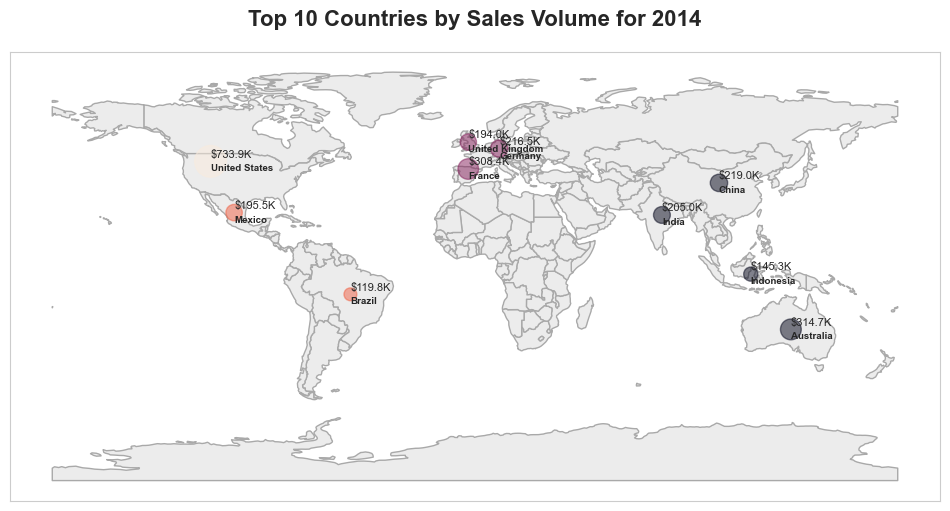

In [56]:
# visualize Top 10 countries by Sales Volume for 2014 on world map
# Get natural earth shapefile path using cartopy's shpreader
shapefile_path = shpreader.natural_earth(
    resolution='110m',
    category='cultural',
    name='admin_0_countries' # World countries
)

# validate file existence
if not os.path.exists(shapefile_path):
    raise FileNotFoundError(f"Shapfile not found at : {shapefile_path}")

# Lord shapefile into GeoPandas GeoDataFrame
world = gpd.read_file(shapefile_path)

# convert column into lower string
world.columns = world.columns.str.lower()
world = world.apply(pd.Series.replace,to_replace = 'United States of America', value='United States')
world_df = world[['name', 'geometry']]


# merge agg_df with world geocodes
merged = world_df.merge(agg_data, left_on='name', right_on='country')
# compute centroids for plotting ponits
merged['longitude'] = merged['geometry'].centroid.x
merged['latitude'] = merged['geometry'].centroid.y

# plot world map
fig, ax = plt.subplots(figsize=(12, 8))
world.plot(ax=ax, color='#ececec', edgecolor='darkgray', linewidth=1)

# scatter plot of countries with sales data
ax.scatter(merged['longitude'], merged['latitude'],
           s = merged['sales']/1400,     # scale bubble size
           c = merged['market'].astype('category').cat.codes,
           alpha=0.5)

# Add sales labels
for idx, row in merged.iterrows():
    ax.text(row['longitude'], row['latitude']+1,
            f"${row['sales']/1000:.1f}K",fontsize=8, va='bottom')
    ax.text(row['longitude'], row['latitude']-1,
            f"{row['country']}",fontsize=7, va='top',fontweight='bold')

# Add titles and labels
ax.set_title("Top 10 Countries by Sales Volume for 2014", fontsize=16, fontweight='bold', y=1.04)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()


## **Sales analysis heat map by day and month**

In [57]:
# Get first_order as per order_id
first_order = (
    order_merged.groupby(['order_id'], as_index=False)['order_date'].first()
)

# Extract month and weekday info
first_order['n_month'] = first_order['order_date'].dt.month
first_order['month'] = first_order['order_date'].dt.month_name()
first_order['n_wod'] = first_order['order_date'].dt.isocalendar().day
first_order['wod'] = first_order['order_date'].dt.day_name()

# Count distinct order by month and weekdays
order_df = (
    first_order.groupby(['n_month', 'month', 'n_wod', 'wod'], as_index=False)
    .agg(
        count_orders = ('order_id', 'nunique')
    )
)

# Compute proportion of total orders
total_orders = order_df['count_orders'].sum()
order_df['proc'] = order_df['count_orders'] / total_orders

# Sort by n_month and n_wod
result = order_df.sort_values(by=['n_month', 'n_wod'])
df = result[['month', 'n_month', 'wod', 'n_wod', 'count_orders', 'proc']]
display(df.head())

,month,n_month,wod,n_wod,count_orders,proc
0,January,1,Monday,1,224,0.008947
1,January,1,Tuesday,2,202,0.008069
2,January,1,Wednesday,3,233,0.009307
3,January,1,Thursday,4,219,0.008748
4,January,1,Friday,5,221,0.008828


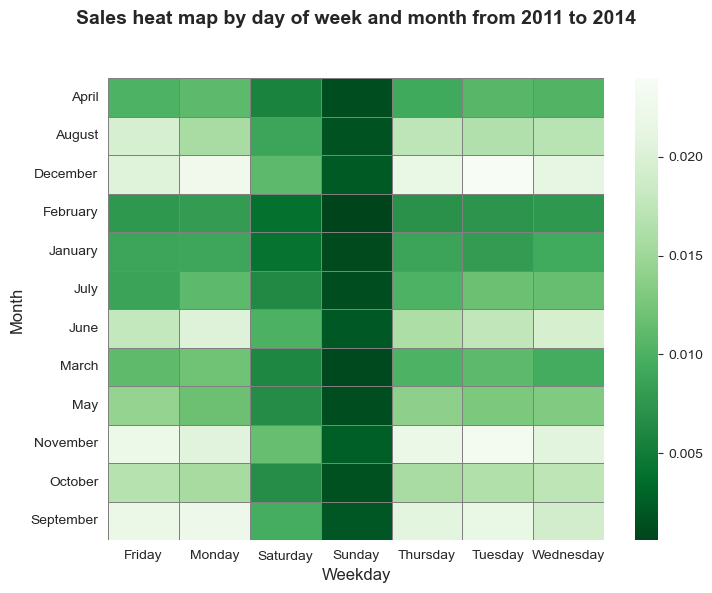

In [58]:
# Visualization of sales analysis by day and months

# Convert 'wod' and 'month' to categorical types
df1 = df.copy()
df1['wod'] = df1['wod'].astype('category')
df1['month'] = df1['month'].astype('category')

# Reorder 'wod' and 'month' based on 'n_wod' and 'n_month'
df1['wod'] = df1['wod'].cat.reorder_categories(
    df1.groupby('wod')['n_wod'].mean().sort_values().index, ordered=True
)
df1['month'] = df1['month'].cat.reorder_categories(
    df1.groupby('month')['n_month'].mean().sort_values(ascending=False).index, ordered=True
)
heat = df1.pivot_table(index='month', columns='wod', values='proc', aggfunc='mean')
# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heat, linewidths=0.5, linecolor='gray',
    cmap='Greens_r'#sns.color_palette(['white','red'],as_cmap=True),
    ,cbar=True
)

# Customize the plot
plt.title("Sales heat map by day of week and month from 2011 to 2014", fontsize=14, fontweight='bold', y=1.10)
plt.xlabel("Weekday", fontsize=12)
plt.ylabel("Month", fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)

# Move x-axis labels to top
#plt.gca().xaxis.tick_top()
#plt.gca().xaxis.set_label_position('top')

# Show the plot
plt.show()


## **Top 5 returnable sub-categories by market**

In [59]:
# Filter only returned orders
returned_df = order_merged[order_merged['returned']].copy()

# count orders per (market + sub-category)
count_df = (
    returned_df.groupby(['market', 'sub-category'],as_index=False)
    .agg(count_orders = ('order_id', 'count'))
)

# Compute percentage within each market
count_df['total_orders'] = count_df.groupby(['market'])['count_orders'].transform('sum')
count_df['perc'] = (count_df['count_orders'] / count_df['total_orders']).round(3)

# Rank sub-categories within each market by perc
count_df['rank'] = count_df.groupby(['market'])['perc'].rank(method='first', ascending=False)

# Label top 5 as sub-category, other as 'Other'
count_df['new_sub_category'] = count_df.apply(
    lambda row: row['sub-category'] if row['rank'] <= 5 else 'Other',
    axis='columns'
)

# Aggregate perc by (market + new_sub_category)
new_df = (
    count_df.groupby(['market', 'new_sub_category'],as_index=False)
    .agg(perc = ('perc', 'sum'))
    .rename(columns={'new_sub_category': 'sub-category'})
    .sort_values(by=['market', 'perc'], ascending=[True, False])
    .reset_index(drop=True)
)
display(new_df.head())

,market,sub-category,perc
0,APAC,Other,0.594
1,APAC,Chairs,0.093
2,APAC,Storage,0.083
3,APAC,Binders,0.080
4,APAC,Fasteners,0.079


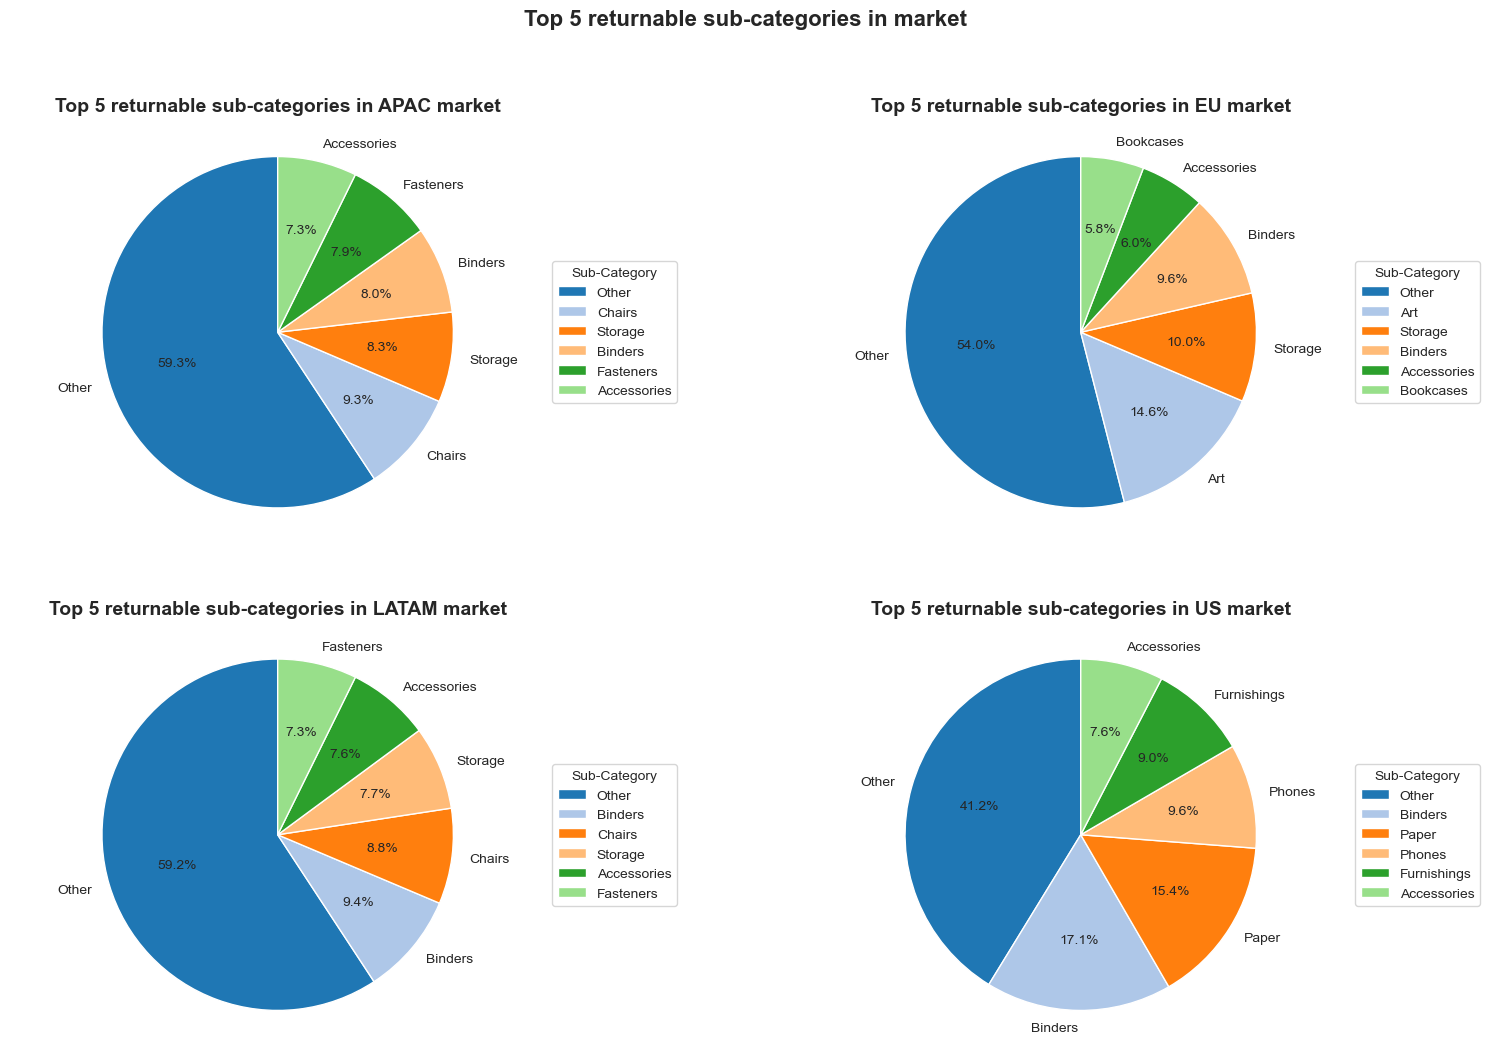

In [60]:
# Visualization of new_df


fig, ax = plt.subplots(2,2,figsize=(15,10))
fig.suptitle(f"Top 5 returnable sub-categories in market", fontsize=16, fontweight='bold', y=1.04)

for i, market in enumerate(new_df["market"].unique()):
    subset = new_df[new_df["market"] == market]
    # pie chart
    row = i // 2
    col_idx = i % 2

    wedges, texts, autotexts = ax[row, col_idx].pie(
        subset["perc"],
        labels=subset["sub-category"],
        autopct=lambda p: f"{p:.1f}%",
        colors=plt.cm.tab20.colors,  # or any colormap you like
        startangle=90
    )
    # Legends
    ax[row, col_idx].legend(title='Sub-Category', loc='center left', bbox_to_anchor=(1,0,0.5, 1))
    # Title
    ax[row, col_idx].set_title(f"Top 5 returnable sub-categories in {market} market", fontsize=14, fontweight='bold', y=1.05)
    # Equal aspect ratio ensures pie is drawn as circle
    ax[row, col_idx].axis('equal')

# Add layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.show()

## **What are number of total and new customers?**

In [61]:
# --- Step 1: Build cte_timespot (all combinations of market × year × quarter) ---
markets = order_merged['market'].unique().tolist()
years = [2011, 2012, 2013, 2014]
quarters = [1, 2, 3, 4]


cte_timespot = pd.MultiIndex.from_product([markets, years, quarters],
                                          names=['market', 'year', 'quarter']).to_frame(index=False) # this added to ensure that u hv complete time series with zeros for missing periods

# --- Step 2: Count unique customers per market, year, quarter
cte_unique_customers = (
    order_merged.groupby(['market', 'order_year', 'order_quarter'], as_index=False)
    .agg(
        uniq_customers = ('customer_id', 'nunique')
    )
)
cte_unique_customers.columns = ['market', 'year', 'quarter', 'uniq_customers']

# --- Step 3: new customers
new_customers = (
    order_merged.groupby(['market', 'first_year', 'first_quarter'], as_index=False)
    .agg(
        new_customers = ('customer_id', 'nunique')
    )
)
new_customers.columns = ['market', 'year', 'quarter', 'new_customers']

# --- Step 4: Join timespot with customers count
customer_df = (
    cte_timespot
    .merge(cte_unique_customers, on = ['market', 'year', 'quarter'], how='left')
    .merge(new_customers, on = ['market', 'year', 'quarter'], how='left')
)

# Fill missing values
customer_df['uniq_customers'] = customer_df['uniq_customers'].fillna(0).astype(int)
customer_df['new_customers'] = customer_df['new_customers'].fillna(0).astype(int)

# --- Step 5: Add qy and row_number
customer_df['qy'] = customer_df.apply(
    lambda row: f"Q{int(row['quarter'])}'{str(row['year'])[-2:]}",
    axis='columns'
)
customer_df['n'] = customer_df.groupby(['market']).cumcount() + 1
display(customer_df.head())

,market,year,quarter,uniq_customers,new_customers,qy,n
0,US,2011,1,121,121,Q1'11,1
1,US,2011,2,180,160,Q2'11,2
2,US,2011,3,228,161,Q3'11,3
3,US,2011,4,305,153,Q4'11,4
4,US,2012,1,135,32,Q1'12,5


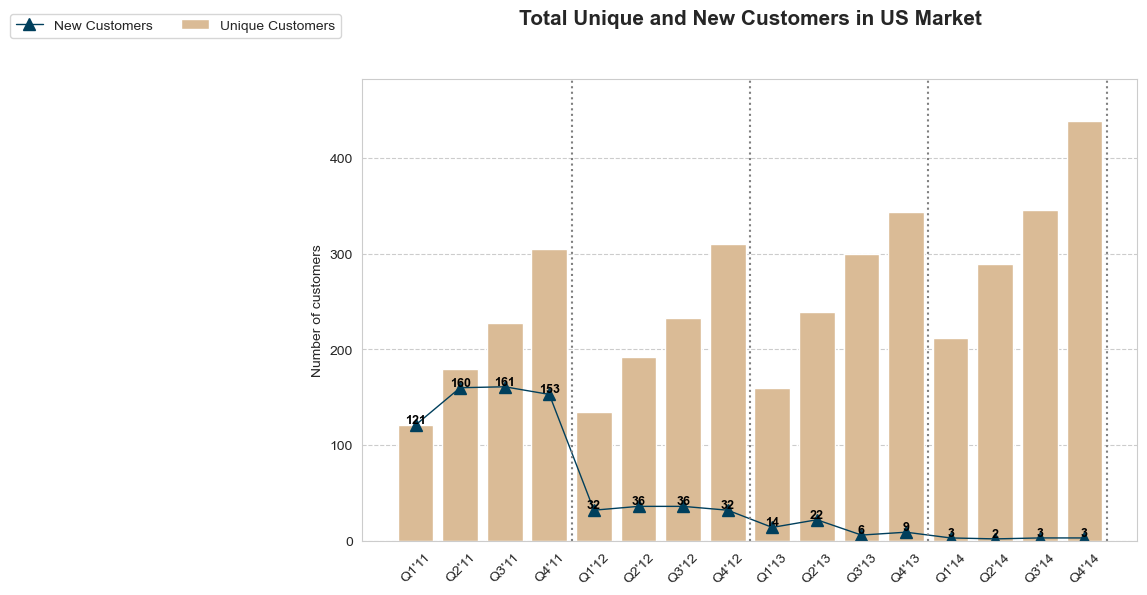

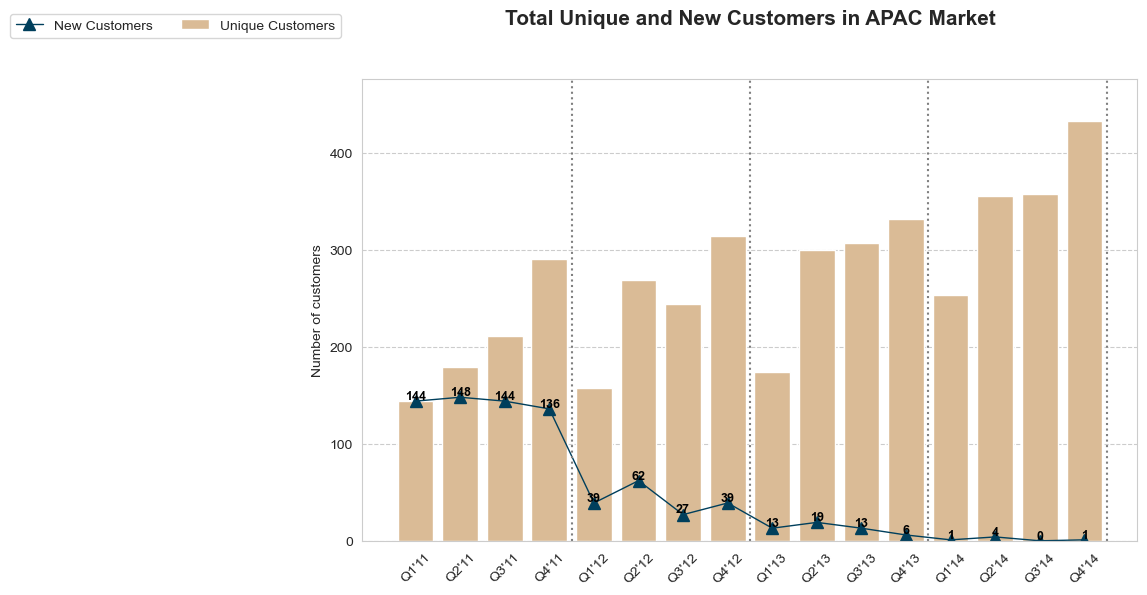

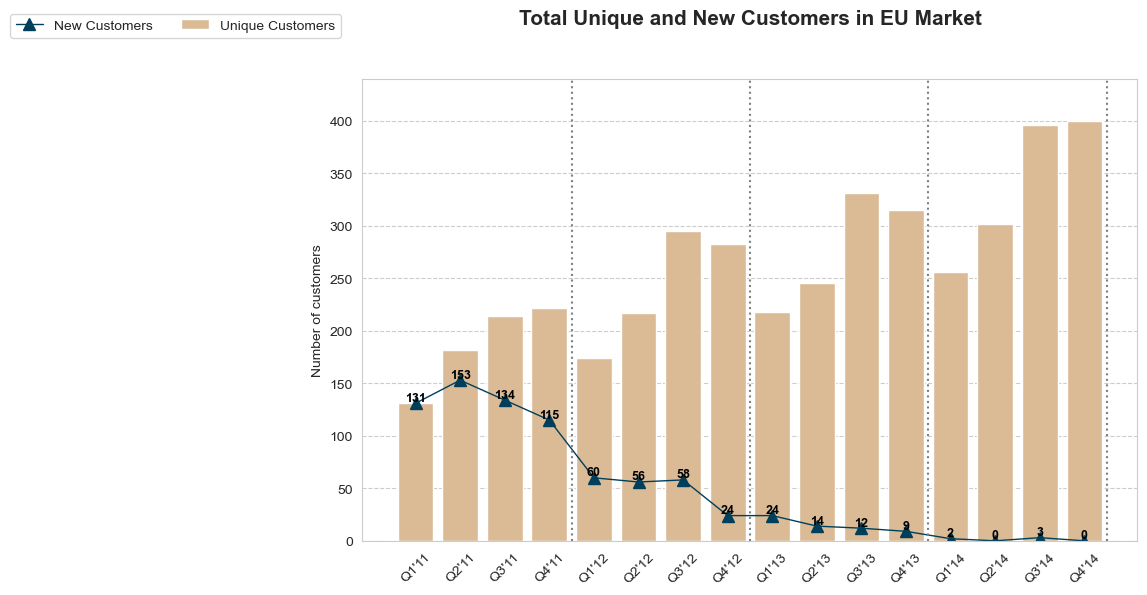

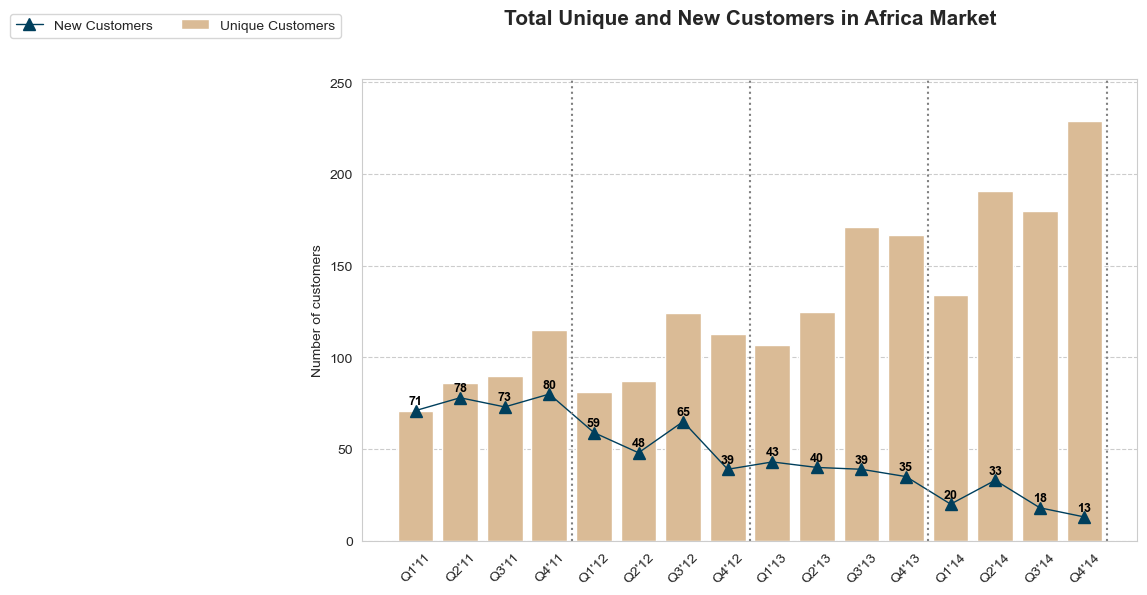

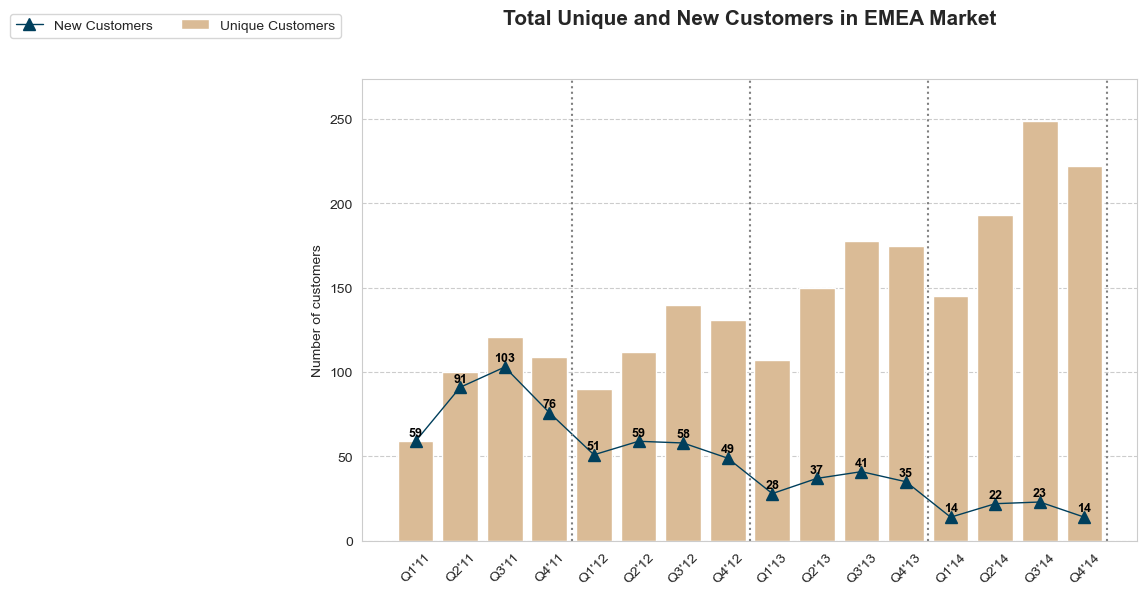

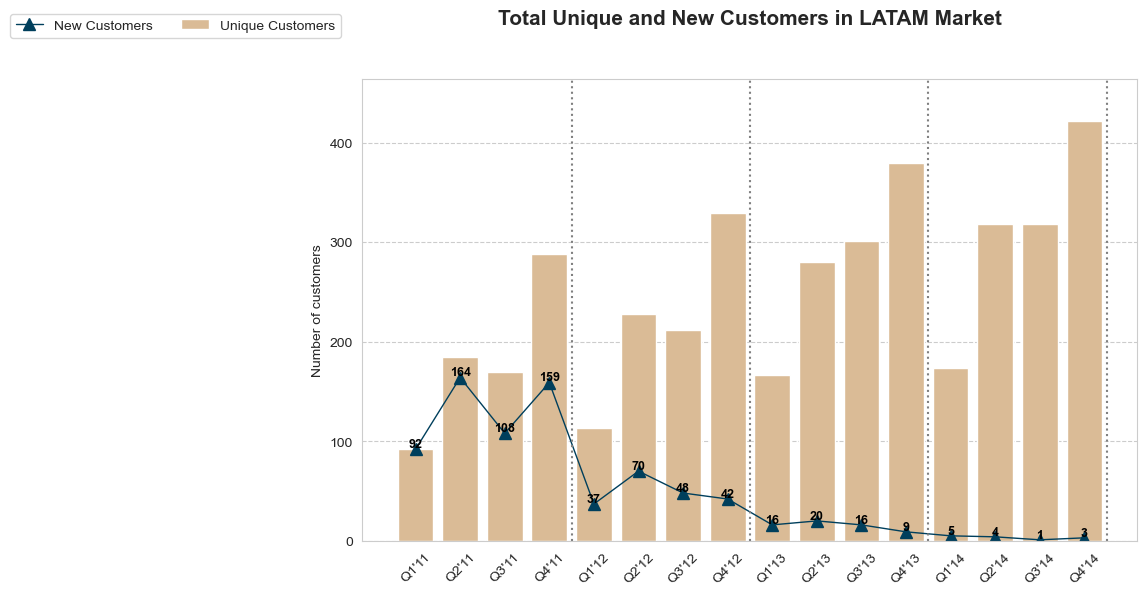

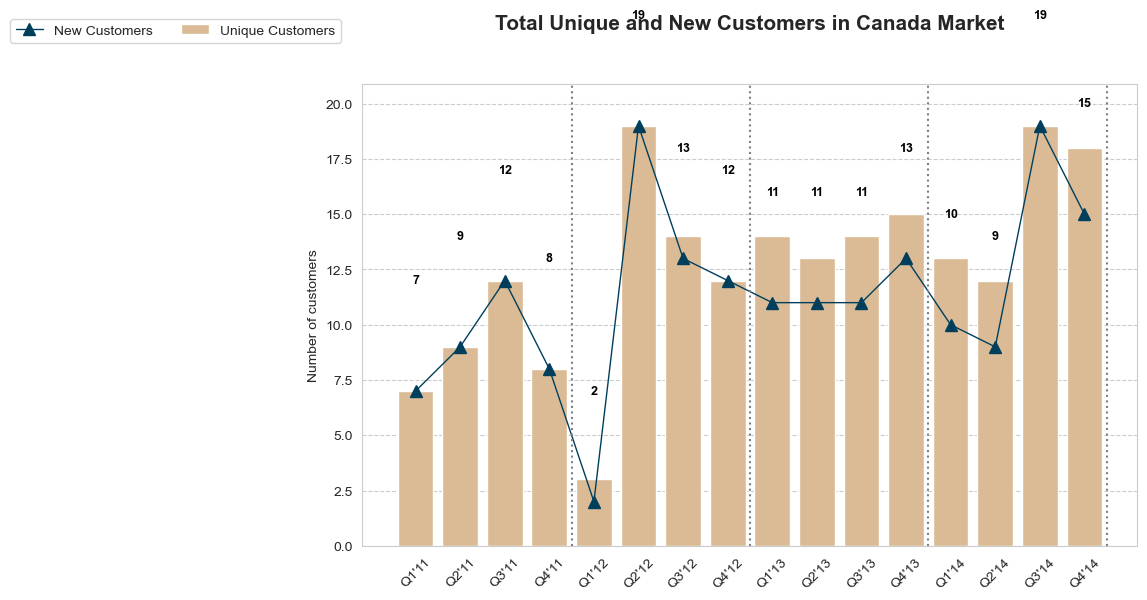

In [62]:
from cProfile import label


for i, market in enumerate(customer_df['market'].unique()):
    subset_df = customer_df[customer_df['market']==market]

    fig, ax = plt.subplots(figsize=(10,6))

    # bar plot for unique customers
    sns.barplot(data=subset_df, x='qy', y='uniq_customers', ax =ax, color='#e5bc8b', label='Unique Customers')
    # line + points for new customers
    ax.plot(subset_df['qy'], subset_df['new_customers'], color='#003f5c', lw=1, marker='^', markersize=8, label='New Customers')
    # Text label above point
    for i, v in zip(subset_df['qy'], subset_df['new_customers']):
        ax.text(i, v+5, f"{v:,.0f}", ha='center', va='center', fontsize=9, fontweight='bold', color='k')
    # Vertical dotted lines
    for x in np.arange(4, len(subset_df['qy'])+1, 4):
        ax.axvline(x-0.5, linestyle='dotted', color='gray')
    # Y-axis limits
    y_max = subset_df['uniq_customers'].max() * 1.1
    ax.set_ylim(0, y_max)
    # X-axis rotation
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45)

    # Add labels and titles
    ax.set_title(f"Total Unique and New Customers in {market} Market", fontsize=15, fontweight='bold', y=1.10)
    ax.set_xlabel("")
    ax.set_ylabel("Number of customers")

    # Add legend
    ax.legend(loc='best', bbox_to_anchor=(0.11,1), bbox_transform=fig.transFigure, ncols=2)
    
    plt.show()
    

## **Percentage of new business revenue generation**

In [63]:
## total sales vs. new sales per market/year/quarter, then calculating the proportion of new business

# --- Step 1: Aggregate sales per order
cte_all_orders = (
    order_merged.groupby(['market', 'order_id', 'order_date', 'customer_id'], as_index=False)
    .agg(sales = ('sales', 'sum'))
)

# --- Step 2: Add year, quarter, and first_year per customer per market ---
cte_all_orders['year'] = cte_all_orders['order_date'].dt.year
cte_all_orders['quarter'] = cte_all_orders['order_date'].dt.quarter

# First order year per customer per market
cte_all_orders = cte_all_orders.sort_values(['market','customer_id','order_date'])
cte_all_orders['first_year'] = (
    cte_all_orders.groupby(['market','customer_id'])['year'].transform('first')
)

# --- Step 3: Aggregate sales per market/year/quarter ---
agg = (
    cte_all_orders.groupby(['market','year','quarter'], as_index=False)
    .agg(
        total_sales=('sales','sum'),
        new_sales=('sales', lambda x: x[cte_all_orders.loc[x.index,'year'] 
                                        == cte_all_orders.loc[x.index,'first_year']].sum())
    )
)

# --- Step 4: Add qy and proc_new_business ---
agg['qy'] = 'Q' + agg['quarter'].astype(str) + "'" + agg['year'].astype(str).str[-2:]
agg['proc_new_business'] = (agg['new_sales'] / agg['total_sales']).round(2)

# --- Step 5: Add row_number per market ---
agg['n'] = agg.groupby('market').cumcount() + 1
agg = agg[['market', 'year', 'quarter', 'qy', 'new_sales', 'total_sales', 'proc_new_business', 'n']]
agg_df = agg.copy()
display(agg_df.head())

,market,year,quarter,qy,new_sales,total_sales,proc_new_business,n
0,APAC,2011,1,Q1'11,93056.5770,93056.5770,1.00,1
1,APAC,2011,2,Q2'11,140930.6277,140930.6277,1.00,2
2,APAC,2011,3,Q3'11,152585.4948,152585.4948,1.00,3
3,APAC,2011,4,Q4'11,252672.5559,252672.5559,1.00,4
4,APAC,2012,1,Q1'12,34389.7815,130485.2997,0.26,5


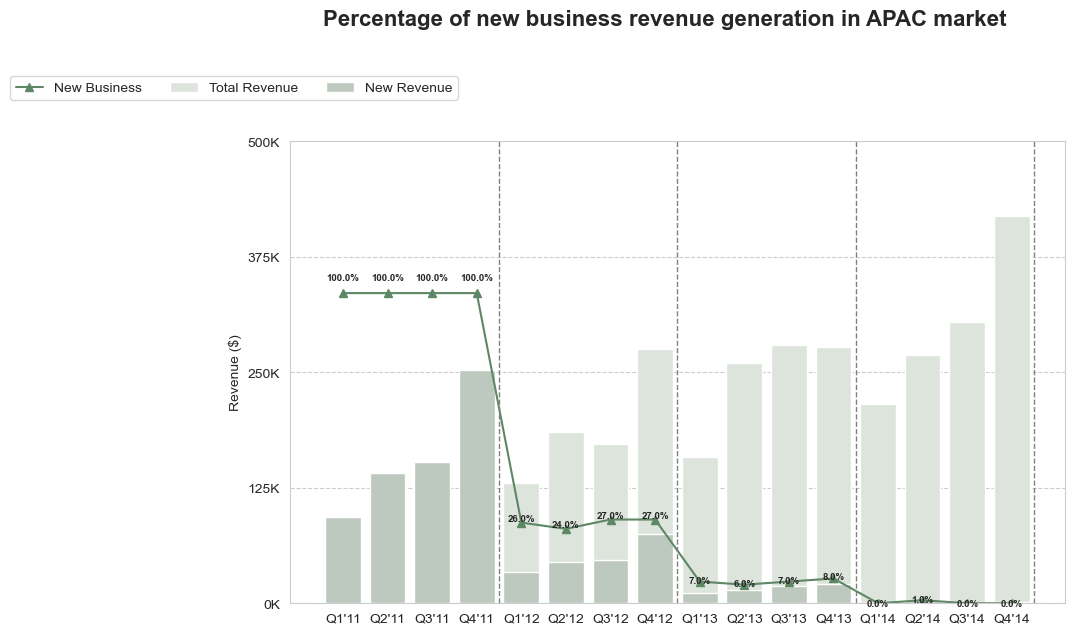

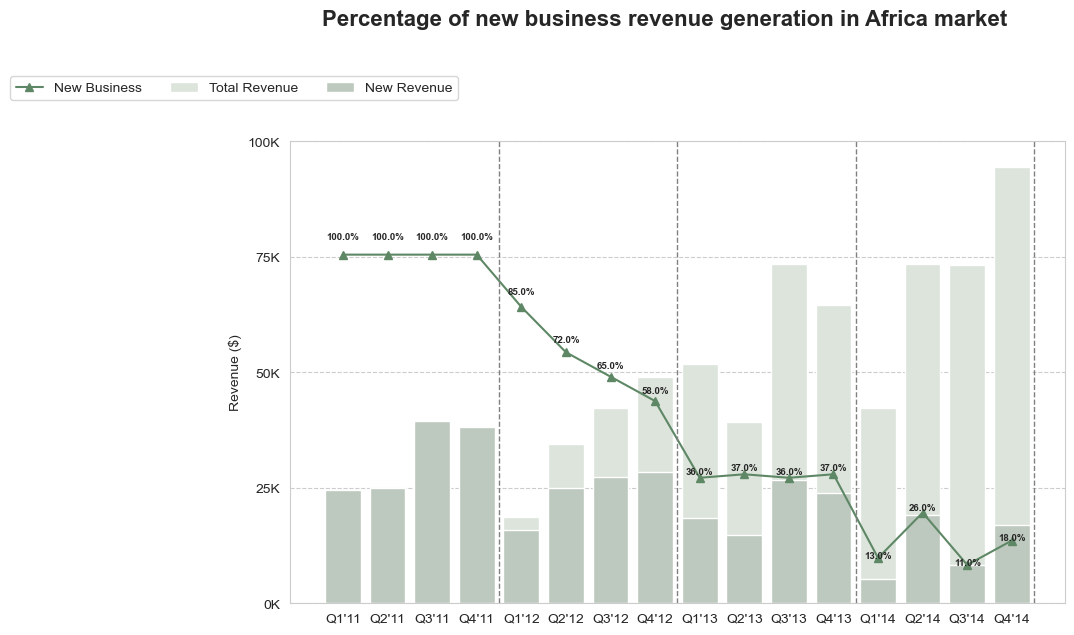

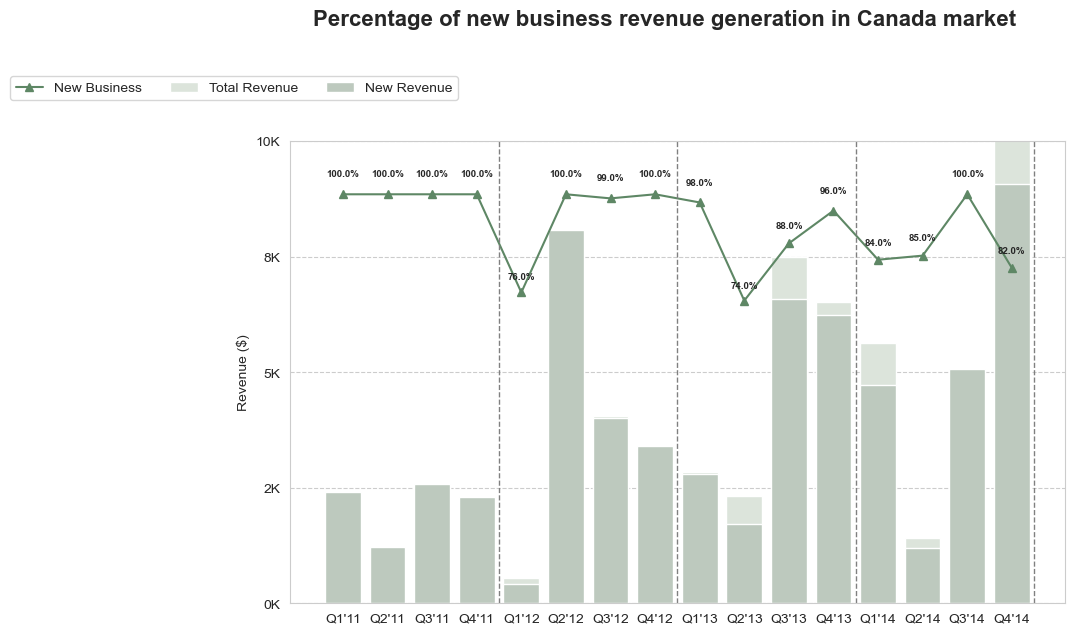

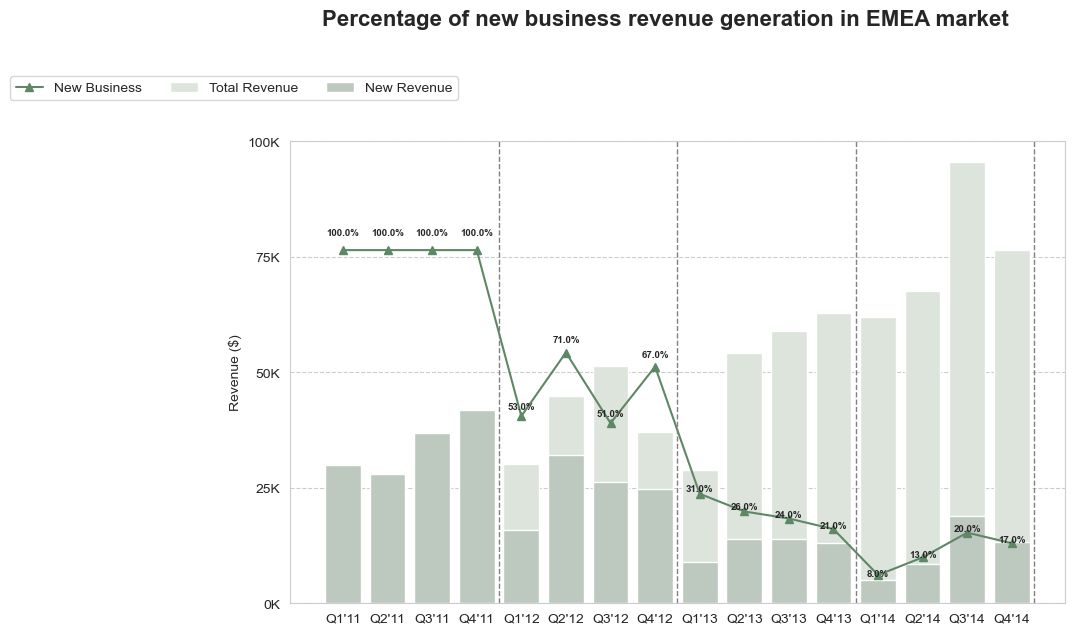

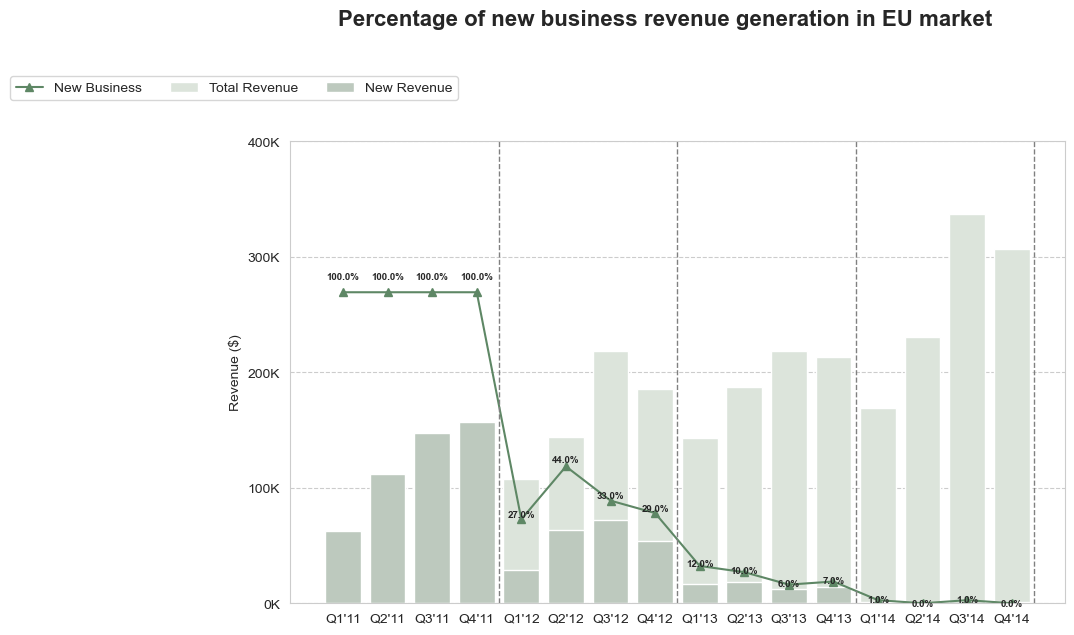

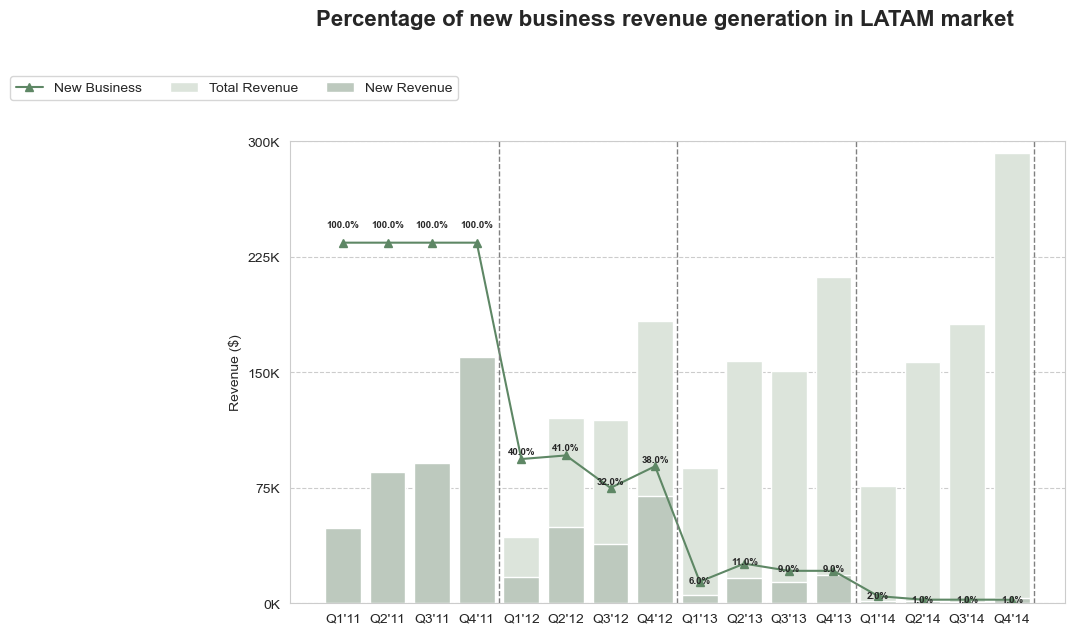

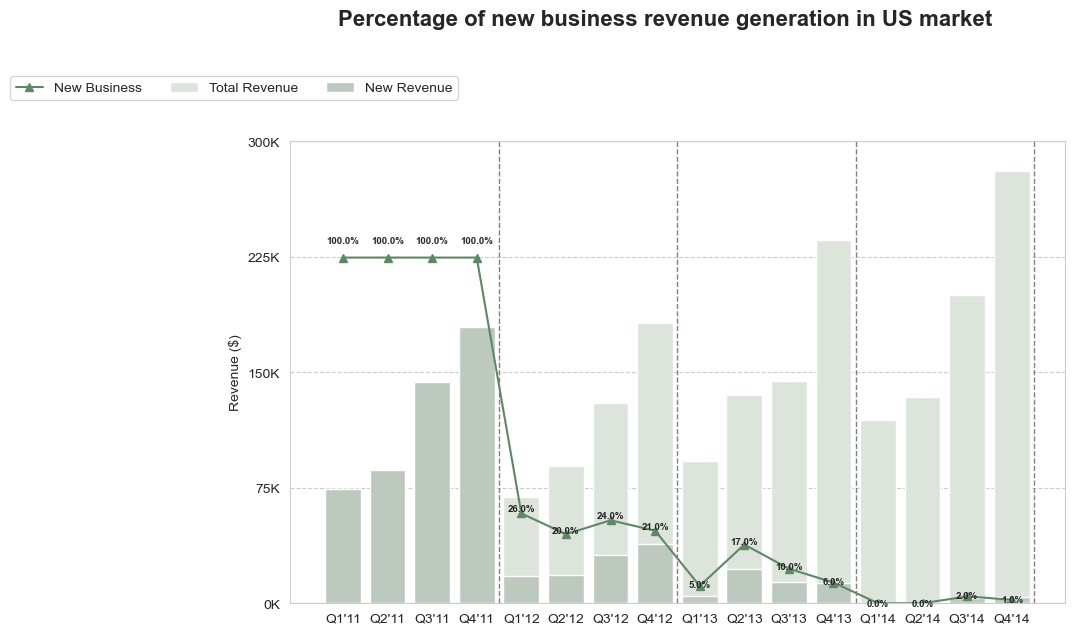

In [66]:
# Visualization of agg_df
for i, market in enumerate(agg_df['market'].unique()):
    data = agg_df[agg_df['market'] == market].copy()

    # Reorder qy by n
    data = data.sort_values('n')
    data['qy_ordered'] = pd.Categorical(data['qy'], categories=data['qy'], ordered=True)
    # scale calculations
    scale_val = data['total_sales'].max()
    scale = scale_val * 0.8
    ai = round(scale_val * 1.1 / 10**np.floor(np.log10(scale_val * 1.1)), 0) * 10**np.floor(np.log10(scale_val * 1.1))


    fig, ax = plt.subplots(figsize=(10,6))
    # bar plot for total_sales
    sns.barplot(data=data, x='qy_ordered', y='total_sales', ax=ax, color='#dbe5da', label='Total Revenue')
    # bar plot for new_sales(overlay)
    sns.barplot(data=data, x='qy_ordered', y='new_sales', ax=ax, color='#bbcbbc', label='New Revenue')
    # line + points for % new business scaled
    line_y = data['proc_new_business']*scale
    ax.plot(data['qy_ordered'], line_y, color='#5e8765', marker='^', markersize=6, label='New Business')
    # Text labels for % new business
    for i, (x,y,percent) in enumerate(zip(data['qy_ordered'], line_y, data['proc_new_business'])):
        ax.text(i, y*1.05, f"{percent:.1%}", ha='center', va='center', fontsize=7, fontweight='bold')

    # Vertical dotted line
    for x in np.arange(4, len(data['qy_ordered'])+1, 4):
        ax.axvline(x-0.5, linestyle='--', linewidth=1,color='gray')

    # Y-axis Fromatting
    #def format_y(x, pos):
     #   if ai >= 1_000_000:
      #      return f"{x/1_000_000:.0f}M"
       # else:
        #    return f"{x/1_000_000:.0f}K"

    #ax.yaxis.set_major_formatter(FuncFormatter(format_y))
    ax.set_ylim(0, ai)
    ax.set_yticks(np.linspace(0, ai, 5))
    ax.set_yticklabels([f"{val/1000:.0f}K" for val in ax.get_yticks()])
        
    # Add title and labels
    fig.suptitle(f"Percentage of new business revenue generation in {market} market", fontsize=16, fontweight='bold', y=1.10)
    ax.set_xlabel("")
    ax.set_ylabel("Revenue ($)")
    # Legend
    ax.legend(loc='upper right', bbox_to_anchor=(0.3, 1), bbox_transform=fig.transFigure, ncols=3)

    plt.show()

# Requirement gatheing of data for seasonal analysis
print(f"Order Date data type: {order_df['order_date'].dtype}")
print(order_df['order_date'].head(1))


# Create new dimensions from order date column like year, month, week, dayofyear, etc.
order_df['order_year'] = order_df['order_date'].dt.year
order_df['order_month'] = order_df['order_date'].dt.month
order_df['order_week'] = order_df['order_date'].dt.isocalendar().week
order_df['order_dayofyear'] = order_df['order_date'].dt.dayofyear   
print("Newly created date dimensions:", '\n', order_df[['order_date','order_year', 'order_month', 'order_week', 'order_dayofyear']].head(4))


# seasonal trend of sales by day of year.
day_df = order_df.groupby(['order_year', 'order_dayofyear'])['sales'].sum().unstack('order_year').fillna(0)

# mean of sales for each day across all years
day_df['mean'] = day_df.mean(axis=1)

# look at day_df data
display(day_df.head())
print()

# plot the total and average number of orders each day across years
fig, ax = plt.subplots(1,2, figsize=(12,6))
day_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Sales each day per year', fontsize=16, fontweight='bold', y=1.04)
ax[0].set_ylabel('Total Sales')

day_df.iloc[:,-1].plot(ax=ax[1])
ax[1].set_title('Average Sales per day Across Year 2011-2014', fontsize=16, fontweight='bold',y=1.04)
ax[1].set_ylabel('Average Sales')

# Add labels and layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


# seasonal trend of sales per week across years
week_df = order_df.groupby(['order_year', 'order_week'])['sales'].sum().unstack('order_year').fillna(0)

# mean of sales for each week across years
week_df['mean'] = week_df.mean(axis=1)

# look at the data
display(week_df.head())
print()
# plot the total quantity of each week across years and aveage quantity of each week across years as well
fig, ax = plt.subplots(1,2, figsize=(12,6))
week_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Sales per Week Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[0].set_ylabel('Total Sales')

week_df.iloc[:,-1].plot(ax=ax[1])
ax[1].set_title('Average Sales per Week Across Years', fontsize=16, fontweight='bold', y=1.02)
ax[1].set_ylabel('Average Sales')

# Add layout and labels
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


# seasonal trend of sales per month across years
month_df = order_df.groupby(['order_year', 'order_month'])['sales'].sum().unstack('order_year').fillna(0)

# mean of a product for each week across years
month_df['mean'] = month_df.mean(axis=1)

# look at the data
display(month_df.head())
# plot the total quantity of each month across years and aveage quantity of each month across years as well
fig, ax = plt.subplots(1, 2, figsize=(12,6))
month_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Sales per Month Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[0].set_ylabel('Total Sales')
ax[0].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

month_df.iloc[:,-1].plot(ax=ax[1], color='tomato')
ax[1].set_title('\nAverage Sales per Month Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[1].set_ylabel('Average Sales')
ax[1].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

# Add label and layouts
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


category_df = order_df.groupby(['order_month', 'order_year', 'category'])['sales'].sum().unstack('order_year').mean(axis=1).unstack('category')
print(category_df, end='\n\n')

# Lets normalize by max of order so we can compare seasonality across the product
scaled_df = category_df.apply(lambda col: col/col.max())

# visualize the average order by month for each category and scaled average order by month for each category
fig, ax = plt.subplots(1, 3, figsize=(20,8))
category_df.plot(ax=ax[0])
ax[0].set_title("Average Sales by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[0].set_ylabel("Averge Sales")
ax[0].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

category_df.plot(kind='bar',ax=ax[1])
ax[1].set_title("Average Sales by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[1].set_ylabel("Averge Sales")
ax[1].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)


scaled_df.plot(ax=ax[2])
ax[2].set_title("Scaled Sales by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[2].set_ylabel("Scaled Averge Sales")
ax[2].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

# Add layout and labels
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


#### **Sales by Region & Country**

**Sales by Region**

region_sales = order_df.groupby("region")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
display(region_sales.round(2).head())
print()
# visualize the trend
plt.figure(figsize=(10,5))
sns.barplot(data=region_sales.reset_index(), x="region", y="sales")
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.ylabel("Sales ($)")
plt.show()


**Sales by Country**

country_sales = order_df.groupby("country")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
display(country_sales.round(2).head(10))
print()


#### **Sales by Segment**

segment_sales = order_df.groupby("segment")[["sales","profit"]].sum()
display(segment_sales.round(2))


#### **Sales by Category & Sub-Category**

category_sales = order_df.groupby("category")[["sales", "profit"]].sum()
subcategory_sales = order_df.groupby(["sub-category"])[["sales", 'profit']].sum()
display(category_sales.round(2))
print()
display(subcategory_sales.head().round(2))
print()
# visualize top 10 sub-categories by sales
#plt.figure(figsize=(12,5))
#sns.barplot(data=subcategory_sales.reset_index().head(10), x="sub-category", y="sales")
#plt.title("Top 10 Sub-Categories by Sales")
#plt.xticks(rotation=45)
#plt.show()



#### **Product-Level Analysis**

**Top-selling products**

top_products = order_df.groupby("product_name")[["sales","profit"]].sum().sort_values("sales", ascending=False)
top_products.head()


**Most profitable products**

top_profit = order_df.groupby("product_name")[["profit"]].sum().sort_values("profit", ascending=False)
top_profit.head()


**Worst-loss products**

loss_products = order_df.groupby("product_name")[["profit"]].sum().sort_values("profit").head()
loss_products


#### **Shipping Mode Analysis**

ship_sales = order_df.groupby("ship_mode")[["sales","profit"]].sum()
display(ship_sales.round(2))
print()
# visualize shipping mode analysis
plt.figure(figsize=(8,4))
sns.barplot(data=ship_sales.reset_index(), x="ship_mode", y="profit")
plt.title("Profit by Ship Mode")
plt.show()


### **Discount Impact on Profit**

plt.figure(figsize=(8,5))
sns.scatterplot(data=order_df, x="discount", y="profit")
plt.title("Discount vs Profit")
plt.show()
